# **1. Import Lib**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from processing_functions.handle_missing_values import * 
from processing_functions.outlier_detection import * 
from analysis_functions.basic_data_inspection import *
from analysis_functions.missing_values_analysis import *
from analysis_functions.univariate_analysis import *
from analysis_functions.bivariate_analysis import *
from analysis_functions.multivariate_analysis  import *

# **2. Load dataset**


In [2]:
# application_record.csv
application_record = pd.read_csv("../full_dataset/Card_Approval_Prediction/application_record.csv")
application_record.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [3]:
# credit_record.csv 
credit_record = pd.read_csv("../full_dataset/Card_Approval_Prediction/credit_record.csv")
credit_record.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


# **3. Inspect data**


## 3.1. For application_record.csv


In [4]:
data_inspector = DataInspector(DataTypesInspectionStrategy())
data_inspector.execute_inspection(df=application_record)


Data Types and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-nul

In [5]:
data_inspector.set_strategy(SummaryStatisticsInspectionStrategy())
data_inspector.execute_inspection(df=application_record)


Summary Statistics (Numerical Features):
                 ID   CNT_CHILDREN  AMT_INCOME_TOTAL     DAYS_BIRTH  \
count  4.385570e+05  438557.000000      4.385570e+05  438557.000000   
mean   6.022176e+06       0.427390      1.875243e+05  -15997.904649   
std    5.716370e+05       0.724882      1.100869e+05    4185.030007   
min    5.008804e+06       0.000000      2.610000e+04  -25201.000000   
25%    5.609375e+06       0.000000      1.215000e+05  -19483.000000   
50%    6.047745e+06       0.000000      1.607805e+05  -15630.000000   
75%    6.456971e+06       1.000000      2.250000e+05  -12514.000000   
max    7.999952e+06      19.000000      6.750000e+06   -7489.000000   

       DAYS_EMPLOYED  FLAG_MOBIL  FLAG_WORK_PHONE     FLAG_PHONE  \
count  438557.000000    438557.0    438557.000000  438557.000000   
mean    60563.675328         1.0         0.206133       0.287771   
std    138767.799647         0.0         0.404527       0.452724   
min    -17531.000000         1.0         0.000

## 3.2. For credit_record.csv


In [6]:
data_inspector.set_strategy(DataTypesInspectionStrategy())
data_inspector.execute_inspection(df=credit_record)


Data Types and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB
None


In [7]:
data_inspector.set_strategy(SummaryStatisticsInspectionStrategy())
data_inspector.execute_inspection(df=credit_record)


Summary Statistics (Numerical Features):
                 ID  MONTHS_BALANCE
count  1.048575e+06    1.048575e+06
mean   5.068286e+06   -1.913700e+01
std    4.615058e+04    1.402350e+01
min    5.001711e+06   -6.000000e+01
25%    5.023644e+06   -2.900000e+01
50%    5.062104e+06   -1.700000e+01
75%    5.113856e+06   -7.000000e+00
max    5.150487e+06    0.000000e+00

Summary Statistics (Categorical Features):
         STATUS
count   1048575
unique        8
top           C
freq     442031


# **4. Create Target Label**


In [8]:
# If STATUS >= 2 -> TARGET = 1 (bad customer), else TARGET = 0 (good customer)
credit_record["TARGET"] = credit_record["STATUS"].apply(lambda x: 1 if x in ["2", "3", "4", "5"] else 0)
# Group by ID to get max TARGET 
target_df = credit_record.groupby("ID")["TARGET"].max().reset_index()
target_df

,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0
...,...,...
45980,5150482,0
45981,5150483,0
45982,5150484,0
45983,5150485,0


In [9]:
num_target_id = target_df["ID"].unique().shape[0]
print(f"Number of unique IDs in target_df: {num_target_id}")

Number of unique IDs in target_df: 45985


# **5. Merge target_df into application_record**


In [10]:
merged_application_record = application_record.merge(target_df, on="ID", how="inner")
merged_application_record.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


In [11]:
data_inspector.set_strategy(DataTypesInspectionStrategy())
data_inspector.execute_inspection(df=merged_application_record)


Data Types and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLA

<h5 style="color: Yellow">
- Sau khi merge chỉ còn có 36457 ID có giá trị. Đã loại bỏ những người không có thông tin tín dụng (lần đầu mở thẻ) và những người không có thông tin cá nhân (do thất lạc dữ liệu hoặc dữ liệu rác từ credit_record) <br>
- Trong đó chỉ có cột OCCUPATION_TYPE là có missing
<h5>


In [12]:
data_inspector.set_strategy(SummaryStatisticsInspectionStrategy())
data_inspector.execute_inspection(df=merged_application_record)


Summary Statistics (Numerical Features):
                 ID  CNT_CHILDREN  AMT_INCOME_TOTAL    DAYS_BIRTH  \
count  3.645700e+04  36457.000000      3.645700e+04  36457.000000   
mean   5.078227e+06      0.430315      1.866857e+05 -15975.173382   
std    4.187524e+04      0.742367      1.017892e+05   4200.549944   
min    5.008804e+06      0.000000      2.700000e+04 -25152.000000   
25%    5.042028e+06      0.000000      1.215000e+05 -19438.000000   
50%    5.074614e+06      0.000000      1.575000e+05 -15563.000000   
75%    5.115396e+06      1.000000      2.250000e+05 -12462.000000   
max    5.150487e+06     19.000000      1.575000e+06  -7489.000000   

       DAYS_EMPLOYED  FLAG_MOBIL  FLAG_WORK_PHONE    FLAG_PHONE    FLAG_EMAIL  \
count   36457.000000     36457.0     36457.000000  36457.000000  36457.000000   
mean    59262.935568         1.0         0.225526      0.294813      0.089722   
std    137651.334859         0.0         0.417934      0.455965      0.285787   
min    -1571

<h5 style="color: Yellow">
- Các cột DAYS_BIRTH và DAYS_EMPLOYED có giá trị quá lớn (về độ lớn) => Có thể đưa về năm
<h5>


# **6. Visualize and Handle missing values**


## 6.1. Analyze and Visualize



Missing Values Count by Column:
OCCUPATION_TYPE    11323
dtype: int64

Visualizing Missing Values...


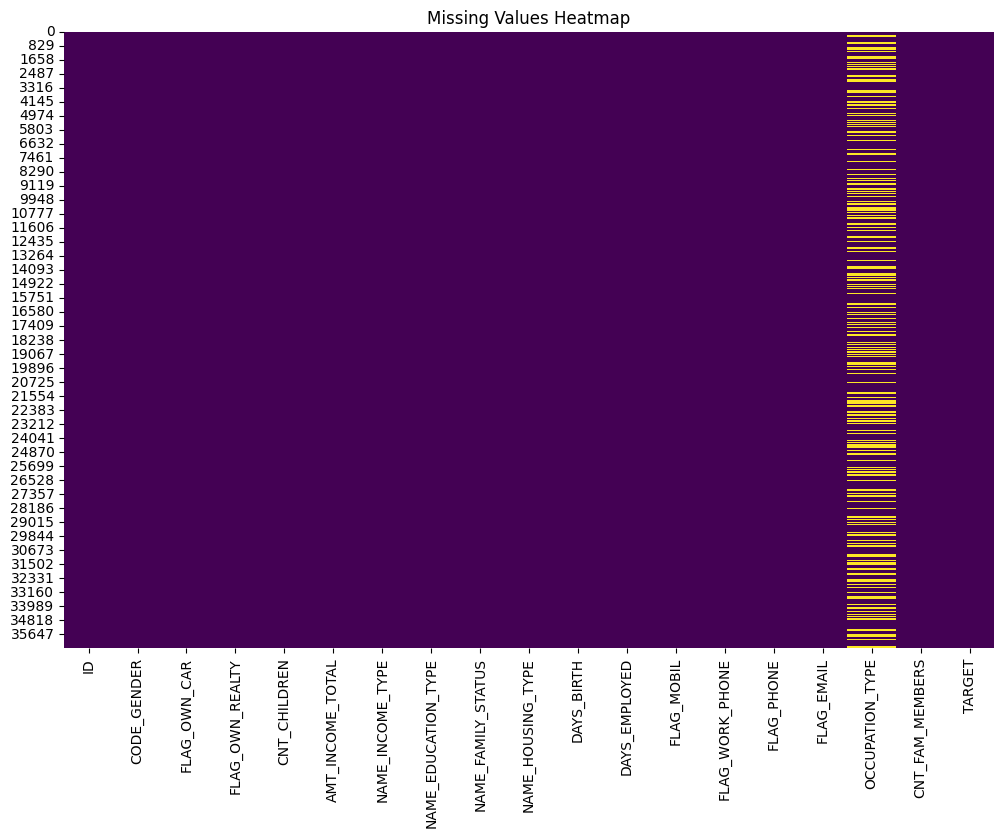

In [13]:
missing_value_analyzer = SimpleMissingValuesAnalysis()
missing_value_analyzer.analyze(df=merged_application_record)

## 6.2. Handle


In [14]:
missing_value_handler = MissingValueHandler(FillMissingValuesStrategy(method="mode"))
merged_application_record = missing_value_handler.handle_missing_values(df=merged_application_record)

2026-01-26 08:02:14,050 - INFO - Executing missing value handling strategy.
2026-01-26 08:02:14,051 - INFO - Filling missing values using method: mode
d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\processing_functions\handle_missing_values.py:93: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[column].fillna(df[column].mode().iloc[0], inplace=True)
d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\processing_functions\handle_missing_values.py:93: FutureWarning: A value is trying to be set on a copy of a DataFram

<h5 style="color: Yellow">
Do OCCUPATION_TYPE là category_column và số lượng thiếu không quá 40% nên xử lý missing value bằng "mode" 
<h5>



Missing Values Count by Column:
Series([], dtype: int64)

Visualizing Missing Values...


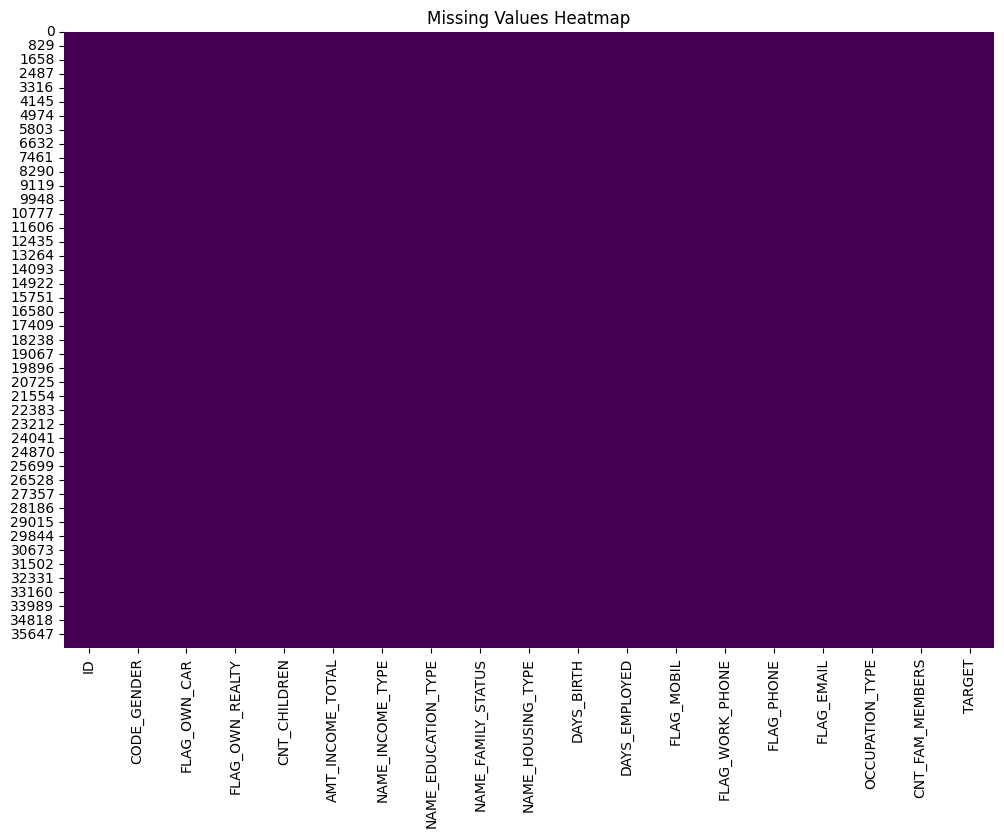

In [15]:
missing_value_analyzer.analyze(df=merged_application_record)

# **7. Process DAYS_BIRTH & DAYS_EMPLOYED**


In [16]:
positive_days_birth = merged_application_record[merged_application_record["DAYS_BIRTH"]>0]["DAYS_BIRTH"].unique()
print(f"Number of positive DAYS_BIRTH entries: {len(positive_days_birth)}")

Number of positive DAYS_BIRTH entries: 0


<h5 style="color: Yellow">
Do dữ liệu trong cột DAYS_BIRTH đều âm (tức là ngày sinh hợp lệ) <br>
-> Ta sẽ chuyển thành cột AGE (tuổi) để dữ liệu trở nên dễ hiểu hơn.
<h5>


In [17]:
positive_days_employed = merged_application_record[merged_application_record["DAYS_EMPLOYED"]>0]["DAYS_EMPLOYED"].unique()
print(f"Number of positive DAYS_EMPLOYED entries: {len(positive_days_employed)} ({positive_days_employed})")


Number of positive DAYS_EMPLOYED entries: 1 ([365243])


<h5 style="color: Yellow">
Do dữ liệu cột "DAYS_EMPLOYED" tồn tại một giá trị > 0 là 365243 ngày ~ 1000 năm (vô lý). <br>
Đây được coi là những người đã nghỉ hưu hay không có công việc hiện tại. <br>
-> Ta sẽ đưa giá trị này về 0 (xem như họ chưa có ngày nào làm việc).
<h5>


In [18]:
# Tính AGE từ DAYS_BIRTH
merged_application_record["AGE"] = (-merged_application_record["DAYS_BIRTH"] / 365).astype(int)

# Xử lý giá trị bất thường trong DAYS_EMPLOYED
merged_application_record["DAYS_EMPLOYED"] = merged_application_record["DAYS_EMPLOYED"].apply(lambda x: 0 if x > 0 else x)
# Tính YEARS_EMPLOYED từ DAYS_EMPLOYED
merged_application_record["YEARS_EMPLOYED"] = (-merged_application_record["DAYS_EMPLOYED"] / 365).astype(int)

merged_application_record[["AGE", "YEARS_EMPLOYED"]].head()

,AGE,YEARS_EMPLOYED
0,32,12
1,32,12
2,58,3
3,52,8
4,52,8


In [19]:
data_inspector.set_strategy(SummaryStatisticsInspectionStrategy())
data_inspector.execute_inspection(df=merged_application_record)


Summary Statistics (Numerical Features):
                 ID  CNT_CHILDREN  AMT_INCOME_TOTAL    DAYS_BIRTH  \
count  3.645700e+04  36457.000000      3.645700e+04  36457.000000   
mean   5.078227e+06      0.430315      1.866857e+05 -15975.173382   
std    4.187524e+04      0.742367      1.017892e+05   4200.549944   
min    5.008804e+06      0.000000      2.700000e+04 -25152.000000   
25%    5.042028e+06      0.000000      1.215000e+05 -19438.000000   
50%    5.074614e+06      0.000000      1.575000e+05 -15563.000000   
75%    5.115396e+06      1.000000      2.250000e+05 -12462.000000   
max    5.150487e+06     19.000000      1.575000e+06  -7489.000000   

       DAYS_EMPLOYED  FLAG_MOBIL  FLAG_WORK_PHONE    FLAG_PHONE    FLAG_EMAIL  \
count   36457.000000     36457.0     36457.000000  36457.000000  36457.000000   
mean    -2200.317168         1.0         0.225526      0.294813      0.089722   
std      2366.796762         0.0         0.417934      0.455965      0.285787   
min    -1571

In [20]:
drop_columns = ["DAYS_BIRTH", "DAYS_EMPLOYED"]
merged_application_record = merged_application_record.drop(columns=drop_columns)

# **8. Detect and Handle Outliers**


## 8.1. AMT_INCOME_TOTAL


2026-01-26 08:02:14,851 - INFO - Executing outlier detection strategy.
2026-01-26 08:02:14,852 - INFO - Detecting outliers using the IQR method.
2026-01-26 08:02:14,854 - INFO - Outliers detected using the IQR method.
2026-01-26 08:02:14,855 - INFO - Visualizing outliers for features: ['AMT_INCOME_TOTAL']


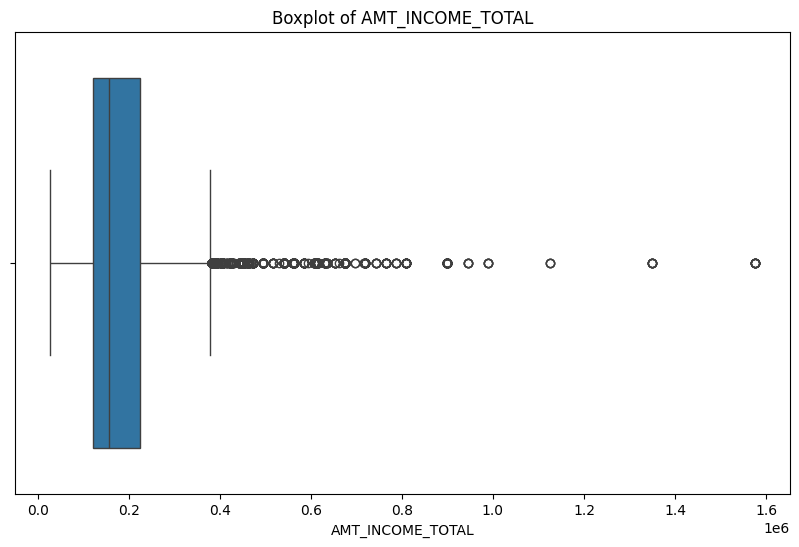

2026-01-26 08:02:14,954 - INFO - Outlier visualization completed.


In [21]:
outlier_detector = OutlierDetector(IQROutlierDetection())
outlier_indices = outlier_detector.detect_outliers(df=merged_application_record, column_name="AMT_INCOME_TOTAL")
outlier_detector.visualize_outliers(df=merged_application_record, features=["AMT_INCOME_TOTAL"])

<h5 style="color: Yellow">
Theo biểu đồ boxplot cho thấy có rất nhiều outliers xuất hiện phải cho thấy xuất hiện nhiều cá nhân có thu nhập hàng năm cao. <br>
-> Có thể sử dụng method "cap" để handle outliers do khi dùng "remove" thì dữ liệu sẽ mất rất nhiều thông tin về các khách hàng có doanh thu hàng năm cao.
<h5>


In [22]:
# Handle outliers with cap method
merged_application_record = outlier_detector.handle_outliers(df=merged_application_record, column_name="AMT_INCOME_TOTAL", method="cap", upper_rate=0.95, lower_rate=0)

2026-01-26 08:02:14,961 - INFO - Executing outlier detection strategy.
2026-01-26 08:02:14,962 - INFO - Detecting outliers using the IQR method.
2026-01-26 08:02:14,965 - INFO - Outliers detected using the IQR method.
2026-01-26 08:02:14,967 - INFO - Capping outliers in the dataset.
2026-01-26 08:02:14,974 - INFO - Outlier handling completed.


<h5 style="color: Yellow">
Với method "cap" tỷ lệ thường được dùng là 95% hoặc 99%. Nhưng với 99% thì không handle hết giá trị ngoại lai nên tôi đã giảm tỷ lệ dần và chọn 95%. <br>
Bên cạnh đó chỉ áp dụng cho upper do không có giá trị ngoại lai. Nếu có không nên dùng lower = 0.05 do khi đó nó sẽ tìm giá trị mà tại đó có 5% người nhỏ hơn (ví dụ có 5% người ít hơn 20000) và cập nhật lại thành 20000. Điều này gây rủi ro do người càng có thu nhập thấp càng dễ nợ hơn.
<h5>


2026-01-26 08:02:14,982 - INFO - Visualizing outliers for features: ['AMT_INCOME_TOTAL']


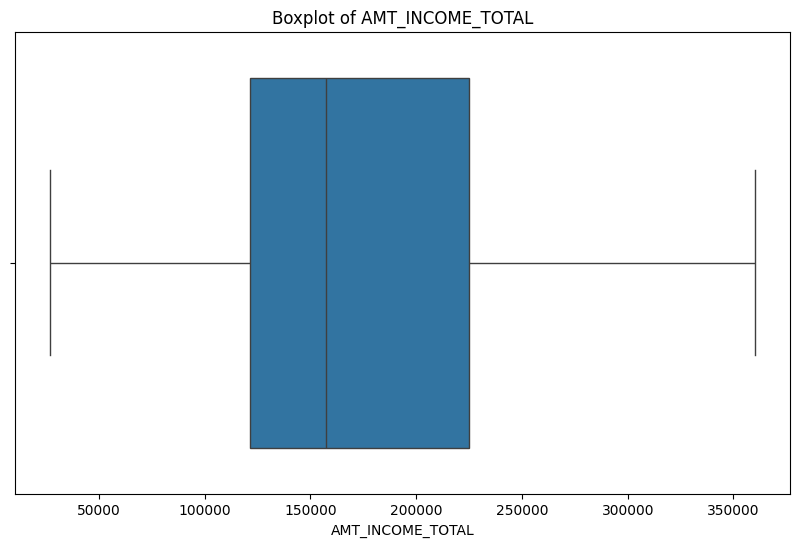

2026-01-26 08:02:15,082 - INFO - Outlier visualization completed.


In [23]:
outlier_detector.visualize_outliers(df=merged_application_record, features=["AMT_INCOME_TOTAL"])

In [24]:
merged_application_record["AMT_INCOME_TOTAL"].describe()

count     36457.000000
mean     180580.802164
std       79145.326680
min       27000.000000
25%      121500.000000
50%      157500.000000
75%      225000.000000
max      360000.000000
Name: AMT_INCOME_TOTAL, dtype: float64

## 8.2. AGE


2026-01-26 08:02:15,096 - INFO - Executing outlier detection strategy.
2026-01-26 08:02:15,097 - INFO - Detecting outliers using the IQR method.
2026-01-26 08:02:15,099 - INFO - Outliers detected using the IQR method.
2026-01-26 08:02:15,100 - INFO - Visualizing outliers for features: ['AGE']


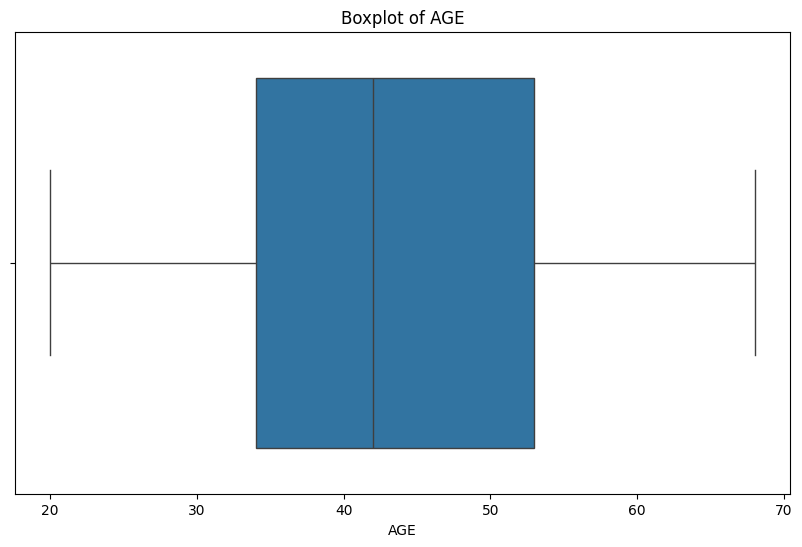

2026-01-26 08:02:15,182 - INFO - Outlier visualization completed.


In [25]:
col_name = "AGE"
outlier_indices = outlier_detector.detect_outliers(df=merged_application_record, column_name=col_name)
outlier_detector.visualize_outliers(df=merged_application_record, features=[col_name])

In [26]:
merged_application_record["AGE"].describe()

count    36457.000000
mean        43.260334
std         11.510414
min         20.000000
25%         34.000000
50%         42.000000
75%         53.000000
max         68.000000
Name: AGE, dtype: float64

<h5 style="color: Yellow">
Cột AGE không có outliers nào.
<h5>


## 8.3. YEARS_EMPLOYED


2026-01-26 08:02:15,197 - INFO - Executing outlier detection strategy.
2026-01-26 08:02:15,198 - INFO - Detecting outliers using the IQR method.
2026-01-26 08:02:15,200 - INFO - Outliers detected using the IQR method.
2026-01-26 08:02:15,201 - INFO - Visualizing outliers for features: ['YEARS_EMPLOYED']


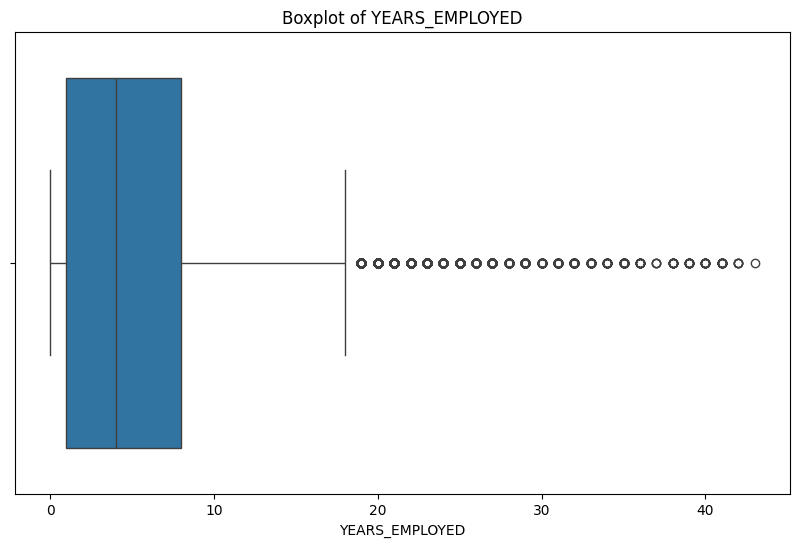

2026-01-26 08:02:15,280 - INFO - Outlier visualization completed.


In [27]:
col_name = "YEARS_EMPLOYED"
outlier_indices = outlier_detector.detect_outliers(df=merged_application_record, column_name=col_name)
outlier_detector.visualize_outliers(df=merged_application_record, features=[col_name])

<h5 style="color: Yellow">
Cột YEARS_EMPLOYED có xuất hiện các outliers bên phải cho thấy có nhiều người có công việc (kinh nghiệm làm việc) từ 20 trở lên. <br>
-> Có thể handle bằng method "cap"
<h5>


In [28]:
merged_application_record[merged_application_record["AGE"] - merged_application_record['YEARS_EMPLOYED'] < 18][['AGE', 'YEARS_EMPLOYED']]

,AGE,YEARS_EMPLOYED
23827,42,25
23828,42,25
23829,42,25
23830,42,25
23831,42,25
23832,42,25
23833,42,25
23834,42,25


In [29]:
merged_application_record = outlier_detector.handle_outliers(df=merged_application_record, column_name="YEARS_EMPLOYED", method="cap", upper_rate=0.94, lower_rate=0)

2026-01-26 08:02:15,295 - INFO - Executing outlier detection strategy.
2026-01-26 08:02:15,296 - INFO - Detecting outliers using the IQR method.
2026-01-26 08:02:15,298 - INFO - Outliers detected using the IQR method.
2026-01-26 08:02:15,299 - INFO - Capping outliers in the dataset.
2026-01-26 08:02:15,305 - INFO - Outlier handling completed.


<h5 style="color: Yellow">
Khi dùng upper = 0.95 thì vẫn tồn tại outliers nên hạ xuống 0.94 thì không còn outliers.
<h5>


2026-01-26 08:02:15,313 - INFO - Visualizing outliers for features: ['YEARS_EMPLOYED']


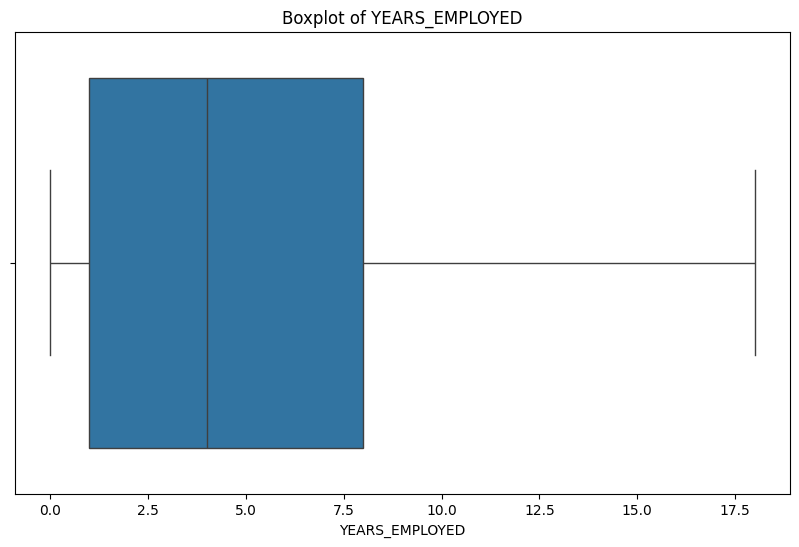

2026-01-26 08:02:15,394 - INFO - Outlier visualization completed.


In [30]:
outlier_detector.visualize_outliers(df=merged_application_record, features=["YEARS_EMPLOYED"])

In [31]:
merged_application_record["YEARS_EMPLOYED"].describe()

count    36457.000000
mean         5.261294
std          5.343061
min          0.000000
25%          1.000000
50%          4.000000
75%          8.000000
max         18.000000
Name: YEARS_EMPLOYED, dtype: float64

## 8.4. CNT_CHILDREN


2026-01-26 08:02:15,409 - INFO - Executing outlier detection strategy.
2026-01-26 08:02:15,410 - INFO - Detecting outliers using the IQR method.
2026-01-26 08:02:15,412 - INFO - Outliers detected using the IQR method.
2026-01-26 08:02:15,413 - INFO - Visualizing outliers for features: ['CNT_CHILDREN']


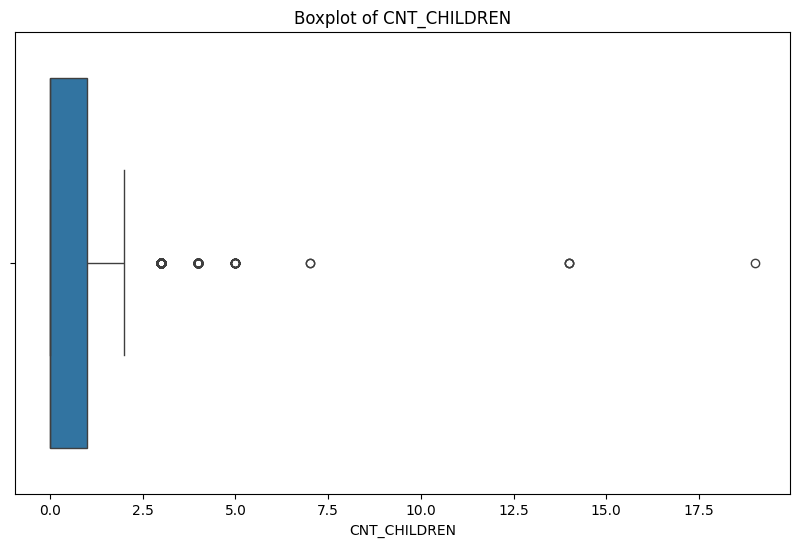

2026-01-26 08:02:15,497 - INFO - Outlier visualization completed.


In [32]:
col_name = "CNT_CHILDREN"
outlier_indices = outlier_detector.detect_outliers(df=merged_application_record, column_name=col_name)
outlier_detector.visualize_outliers(df=merged_application_record, features=[col_name])

<h5 style="color: Yellow">
Cột CNT_CHILDREN có xuất hiện vài outliers bên phải cho thấy có vài người có từ 3 người con trở lên. <br>
Có một vài người có tới 7-8 hoặc 10 mấy người con sẽ có thể gây nhiễu mô hình <br>
-> Không nên dùng "cap" vì gánh nặng tài chính 5 con sẽ ít hơn 10 con nhưng ta lại gán chúng bằng chung một giá trị sẽ gây ra dữ liệu khác với thực tế. Có thể dùng method "remove".
<h5>


<h5 style="color: Yellow">
Ban đầu tôi dùng remove. Nhưng khi phân tích đơn biến thì tôi nghĩ nên dùng binning cho cột CNT_CHILDREN để có thể xử lý các giá trị liên tục thành các nhóm đại diện. Giúp làm gom các giá trị rủi ro về 1 nhóm. Do đó không cần remove nhóm outlier này để tránh mất dữ liệu. 
<h5>


In [33]:
# merged_application_record = outlier_detector.handle_outliers(df=merged_application_record, column_name="CNT_CHILDREN", method="remove", upper_rate=0.99, lower_rate=0)

2026-01-26 08:02:15,507 - INFO - Visualizing outliers for features: ['CNT_CHILDREN']


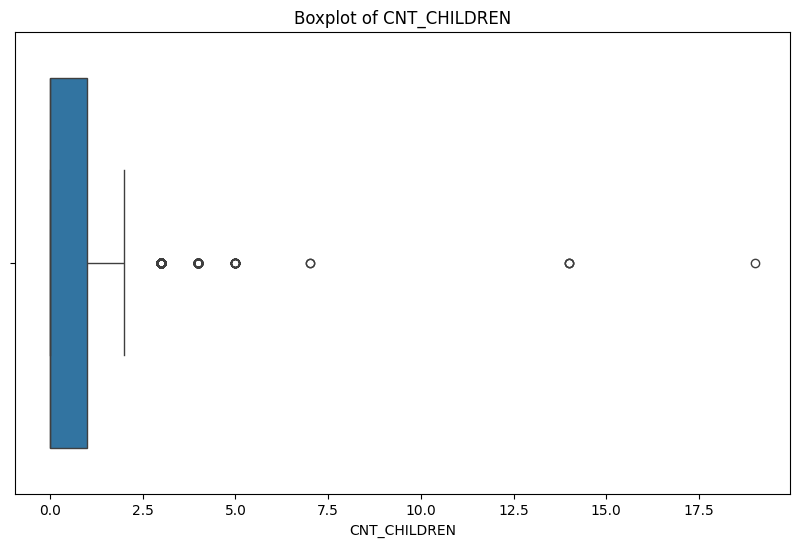

2026-01-26 08:02:15,592 - INFO - Outlier visualization completed.


In [34]:
outlier_detector.visualize_outliers(df=merged_application_record, features=["CNT_CHILDREN"])

In [35]:
data_inspector.set_strategy(SummaryStatisticsInspectionStrategy())
data_inspector.execute_inspection(df=merged_application_record)


Summary Statistics (Numerical Features):
                 ID  CNT_CHILDREN  AMT_INCOME_TOTAL  FLAG_MOBIL  \
count  3.645700e+04  36457.000000      36457.000000     36457.0   
mean   5.078227e+06      0.430315     180580.802164         1.0   
std    4.187524e+04      0.742367      79145.326680         0.0   
min    5.008804e+06      0.000000      27000.000000         1.0   
25%    5.042028e+06      0.000000     121500.000000         1.0   
50%    5.074614e+06      0.000000     157500.000000         1.0   
75%    5.115396e+06      1.000000     225000.000000         1.0   
max    5.150487e+06     19.000000     360000.000000         1.0   

       FLAG_WORK_PHONE    FLAG_PHONE    FLAG_EMAIL  CNT_FAM_MEMBERS  \
count     36457.000000  36457.000000  36457.000000     36457.000000   
mean          0.225526      0.294813      0.089722         2.198453   
std           0.417934      0.455965      0.285787         0.911686   
min           0.000000      0.000000      0.000000         1.000000   

In [36]:
data_inspector.set_strategy(DataTypesInspectionStrategy())
data_inspector.execute_inspection(df=merged_application_record)


Data Types and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  FLAG_MOBIL           36457 non-null  int64  
 11  FLAG_WORK_PHONE      36457 non-null  int64  
 12  FLAG_PHONE           36457 non-null  int64  
 13  FLAG_EMAIL           36457 non-null  int64  
 14  OCCUPATION_TYPE      36457 non-null  object 
 15  CNT

# **9. Univariate Analysis**


## 9.1. Numeric_columns


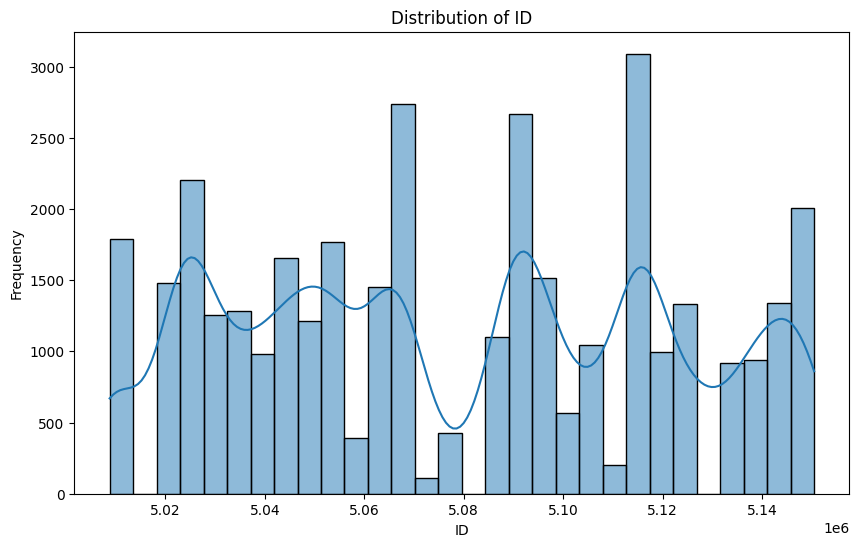

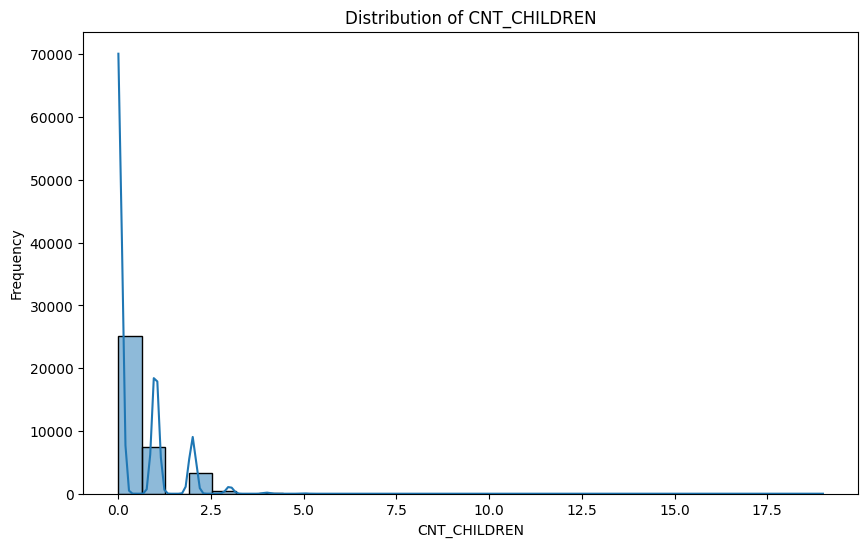

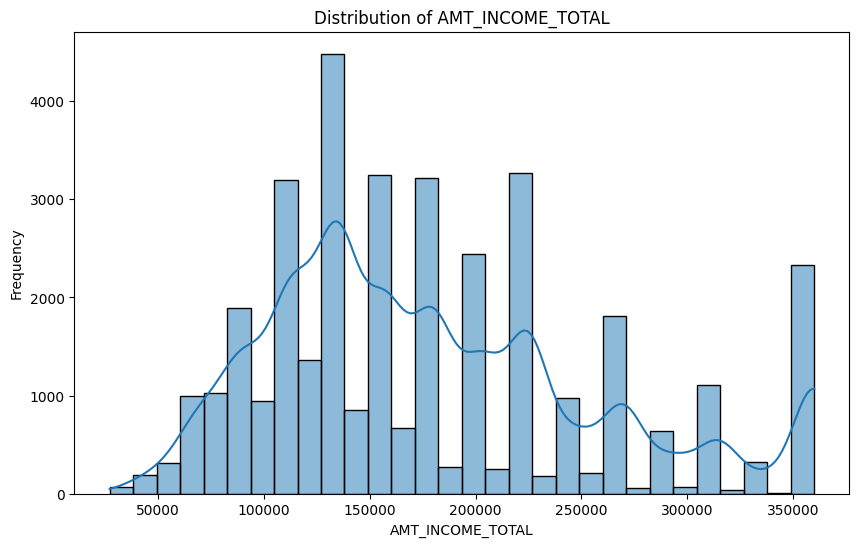

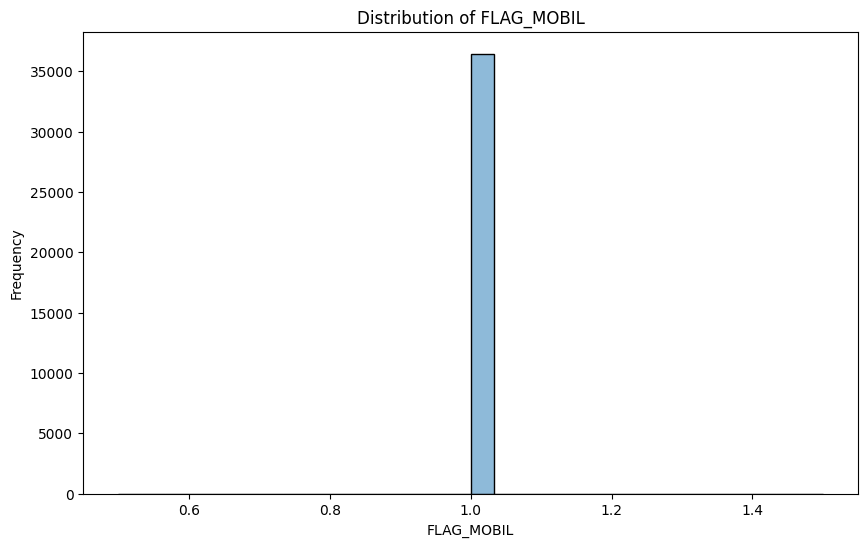

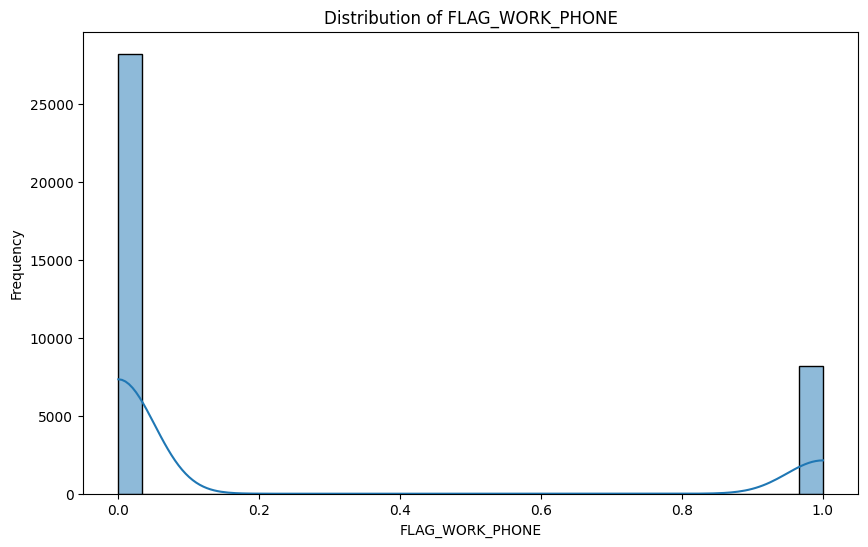

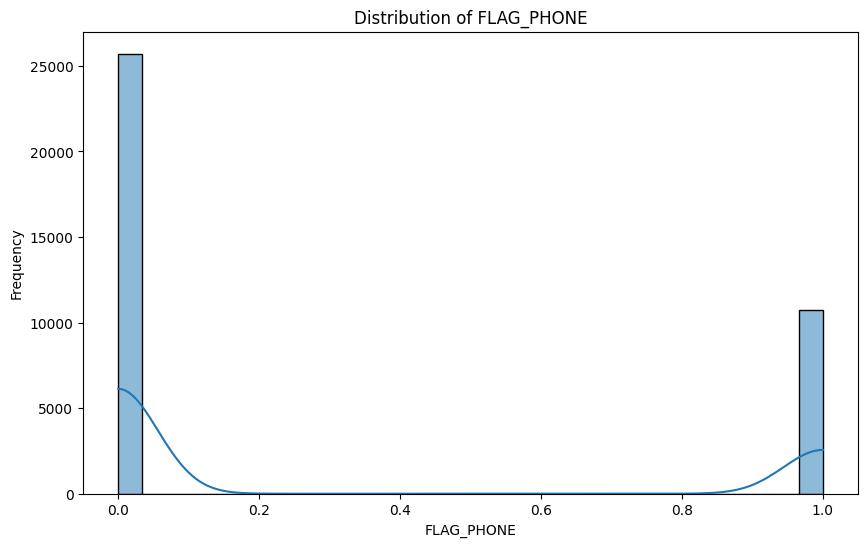

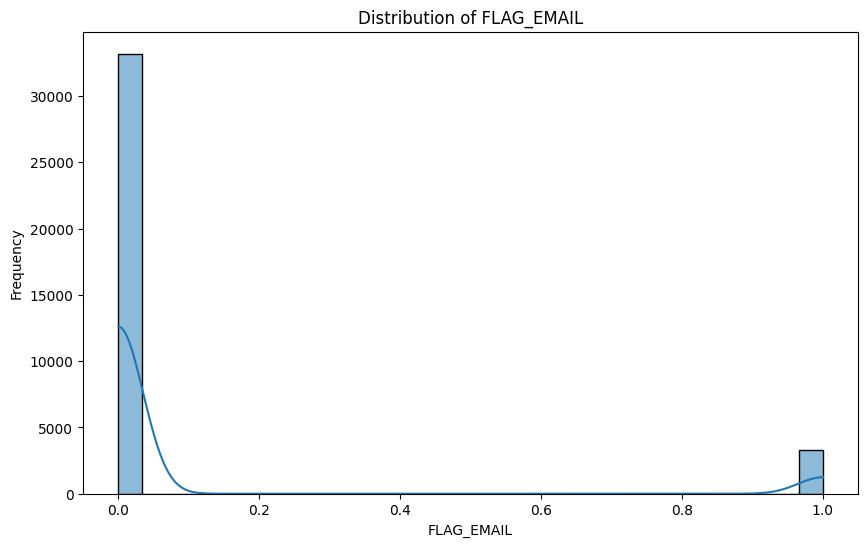

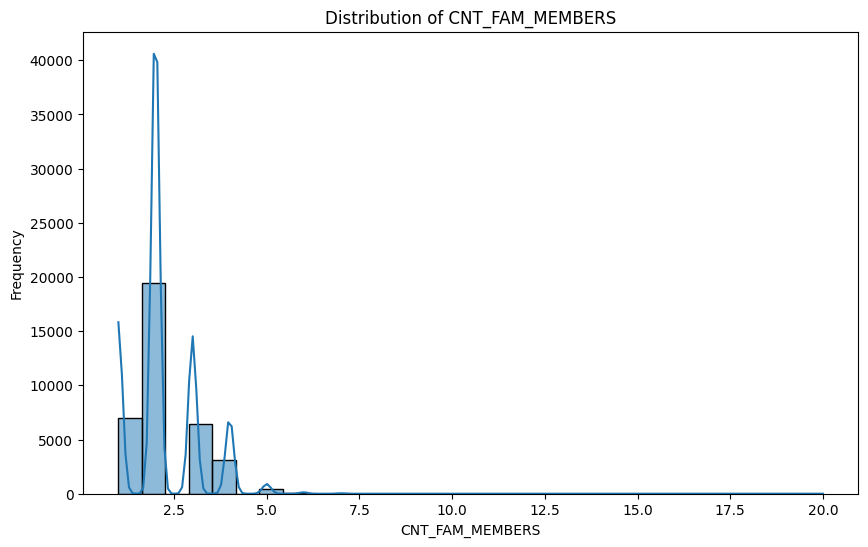

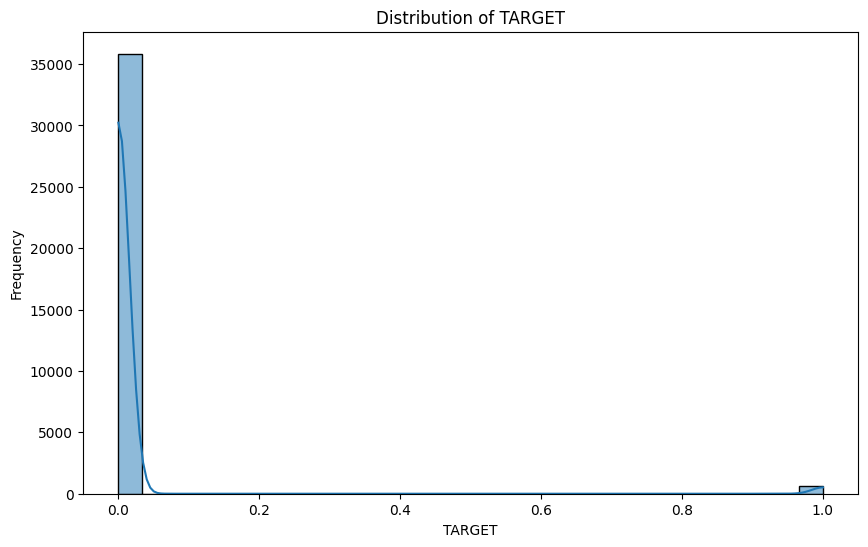

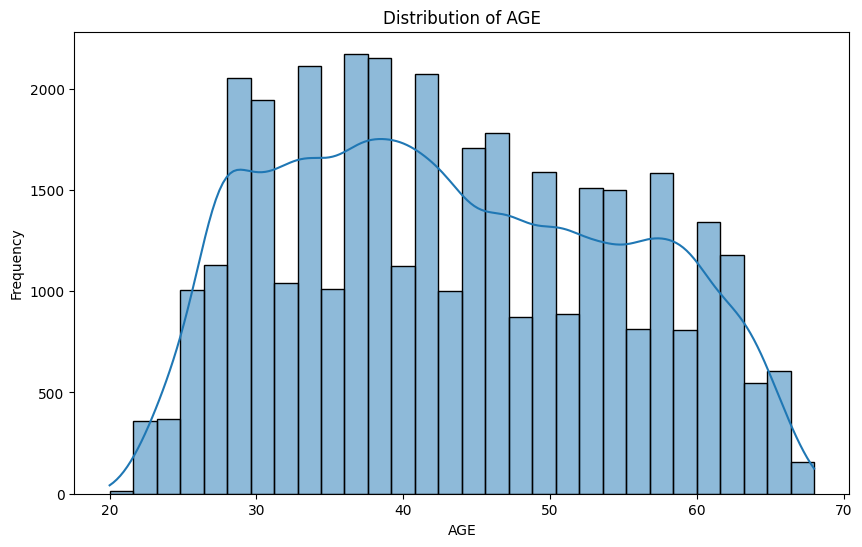

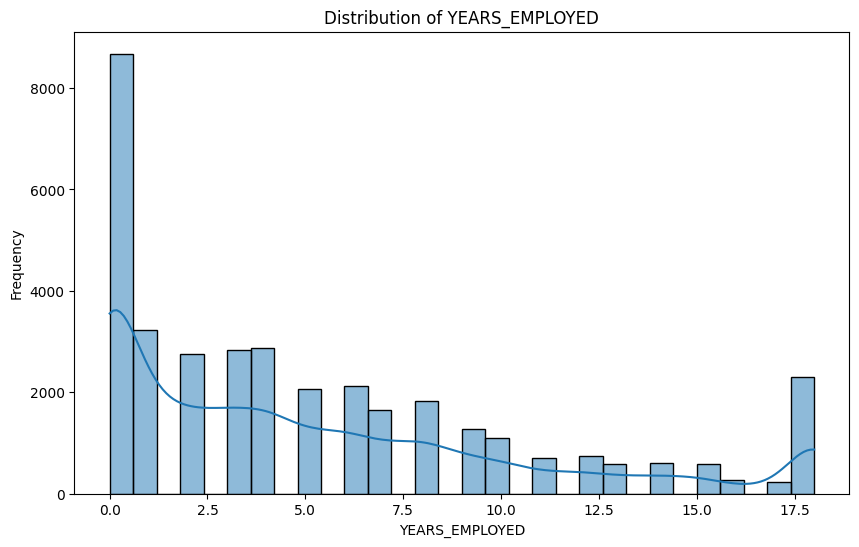

In [37]:
numeric_columns = merged_application_record.select_dtypes(include=["number"]).columns.tolist()

univariate_analyzer = UnivariateAnalyzer(NumericalUnivariateAnalysis())
for col in numeric_columns:
    univariate_analyzer.execute_analysis(df=merged_application_record, feature=col)

<h5 style="color: Yellow">

- CNT_CHILDREN: Đây là biến liên tục nhưng có các giá trị cao bất thường (do không handle outlier). <br>
  -> Dùng binning để chuyển biến liên tục thành biến phân loại để giúp mô hình phân loại tốt hơn.

- AMT_INCOME_TOTAL: Phân phối lệch phải

- FLAG_MOBIL: Tất cả record chỉ có một giá trị duy nhất là 1.0 không có giá trị cho mô hình dự đoán. <br>
  -> Có thể drop

- FLAG_WORK_PHONE: Đây là biến phân loại (0 | 1). Chủ yếu tập trung ở giá trị 0. Cho thấy phân khúc khách hàng thường ít sử dụng điện thoại công việc.

- FLAG_PHONE: Đây là biến phân loại (0 | 1). Chủ yếu tập trung ở giá trị 0. Cho thấy phân khúc khách hàng thường ít sử dụng điện thoại.

- FLAG_EMAIL: Đây là biến phân loại (0 | 1). Chủ yếu tập trung ở giá trị 0. Cho thấy phân khúc khách hàng thường ít sử dụng email.
  - CNT_FAM_MEMBERS: Đây là biến liên tục. <br>
    -> Dùng binning để chuyển biến liên tục thành biến phân loại để giúp mô hình phân loại tốt hơn.

  - TARGET: Dữ liệu bị imbalanced lệch rất nhiều về phía 0 (good customer). <br>
    -> Có thể dùng undersampling

  - AGE: Phân phối khá đều, độ tuổi tập trung từ khoảng 25-65 tuổi.

  - YEARS_EMPLOYED: Phân phối lệch phải

<h5>


In [38]:
# Binning CNT_CHILDREN
bin_edges = [-1, 0, 1, 2, np.inf]
bin_labels = ['children_0', 'children_1', 'children_2', 'children_3+']
merged_application_record['CNT_CHILDREN_BINNED'] = pd.cut(merged_application_record['CNT_CHILDREN'], bins=bin_edges, labels=bin_labels)

In [39]:
# Binning CNT_FAM_MEMBERS
bin_edges = [0, 1, 2, 3, 4, np.inf]
bin_labels = ["fam_1", "fam_2", "fam_3", "fam_4", "fam_5+"]
merged_application_record['CNT_FAM_MEMBERS_BINNED'] = pd.cut(merged_application_record["CNT_FAM_MEMBERS"], bins=bin_edges, labels=bin_labels)

In [40]:
# Drop FLAG_MOBIL because it has only one unique value
merged_application_record = merged_application_record.drop(columns=["FLAG_MOBIL"])

In [41]:
# Drop original columns after binning
drop_columns = ["CNT_CHILDREN", "CNT_FAM_MEMBERS"]
merged_application_record = merged_application_record.drop(columns=drop_columns)

In [42]:
# # Undersampling TARGET
# count_target_0 = merged_application_record[merged_application_record["TARGET"] == 0].shape[0]
# count_target_1 = merged_application_record[merged_application_record["TARGET"] == 1].shape[0]
# print(f"Count of TARGET = 0: {count_target_0}")
# print(f"Count of TARGET = 1: {count_target_1}")
# df_target_0 = merged_application_record[merged_application_record["TARGET"] == 0]
# df_target_1 = merged_application_record[merged_application_record["TARGET"] == 1]
# df_target_0_undersampled = df_target_0.sample(n=count_target_1, random_state=42)
# merged_application_record = pd.concat([df_target_0_undersampled, df_target_1], axis=0).reset_index(drop=True)

# data_inspector.set_strategy(DataTypesInspectionStrategy())
# data_inspector.execute_inspection(df=merged_application_record)

<h5 style="color: Yellow">
Ban đầu tôi định dùng undersampling cho dữ liệu nhưng do số lượng TARGET = 0 chỉ có 603 rất thấp so với lượng TARGET = 1 với 35346. <br> 
-> Do đó nếu dùng undersampling thì dữ liệu chỉ còn 1206. Mất hơn 90% dữ liệu. <br>
-> Vì vậy tui sẽ không dùng undersampling cho tập dữ liệu.
</h5>


In [43]:
# # SMOTE Oversampling TARGET
# from imblearn.over_sampling import SMOTE
# from sklearn.preprocessing import LabelEncoder

# # Separate features and target
# X = merged_application_record.drop(columns=["TARGET", "ID"])
# y = merged_application_record["TARGET"]

# # Encode categorical variables
# categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
# X_encoded = X.copy()

# # Use LabelEncoder for each categorical column
# label_encoders = {}
# for col in categorical_cols:
#     le = LabelEncoder()
#     X_encoded[col] = le.fit_transform(X[col].astype(str))
#     label_encoders[col] = le

# # Apply SMOTE
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

# # Decode categorical columns back to original values
# X_resampled_decoded = pd.DataFrame(X_resampled, columns=X.columns)
# for col in categorical_cols:
#     # Round the values and convert to int for decoding
#     X_resampled_decoded[col] = X_resampled_decoded[col].round().astype(int)
#     # Clip values to valid range
#     X_resampled_decoded[col] = X_resampled_decoded[col].clip(0, len(label_encoders[col].classes_) - 1)
#     # Decode back to original labels
#     X_resampled_decoded[col] = label_encoders[col].inverse_transform(X_resampled_decoded[col])

# # Combine back with target
# merged_application_record = pd.concat([X_resampled_decoded.reset_index(drop=True), 
#                                        y_resampled.reset_index(drop=True)], axis=1)

# # Inspect the result
# data_inspector.set_strategy(DataTypesInspectionStrategy())
# data_inspector.execute_inspection(df=merged_application_record)

## 9.2. Category_columns


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


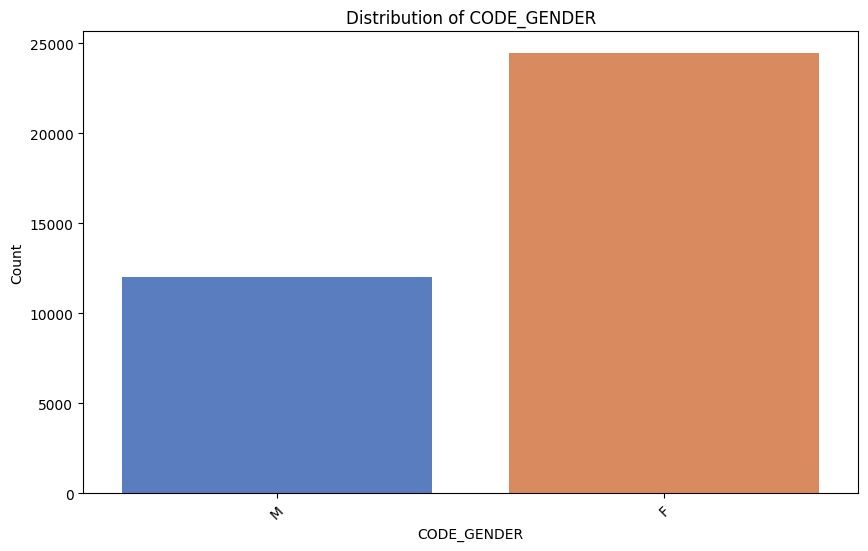

d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


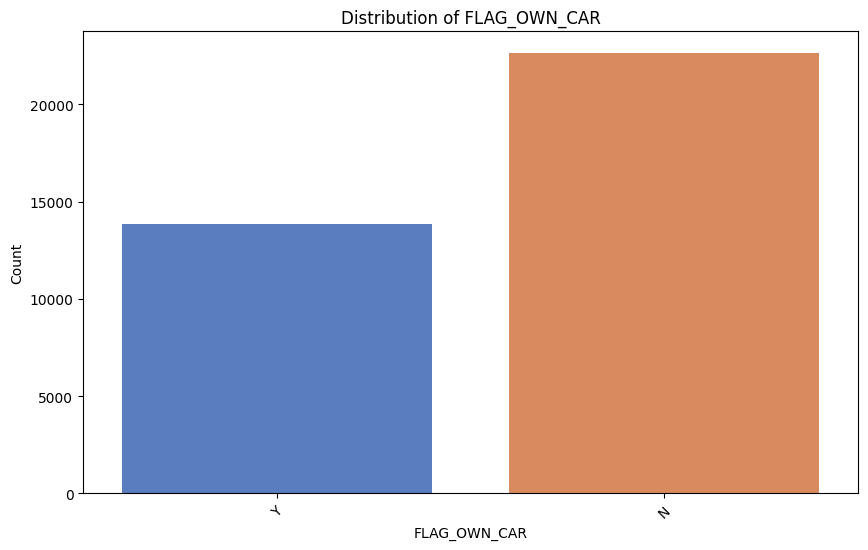

d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


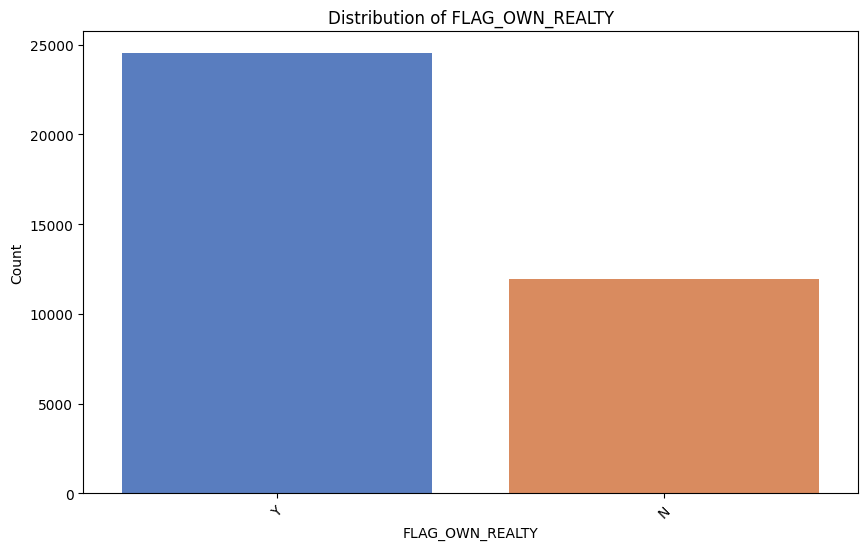

d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


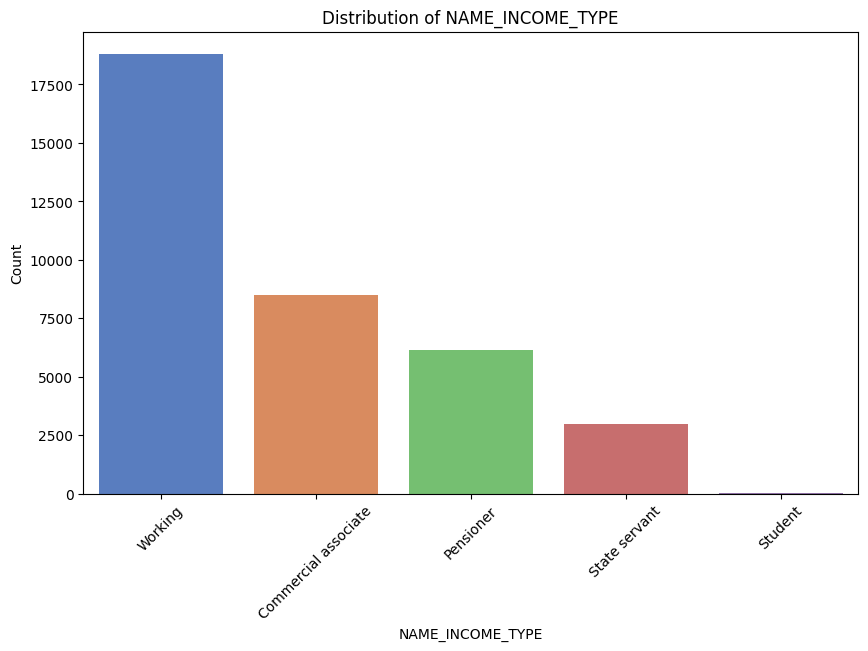

d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


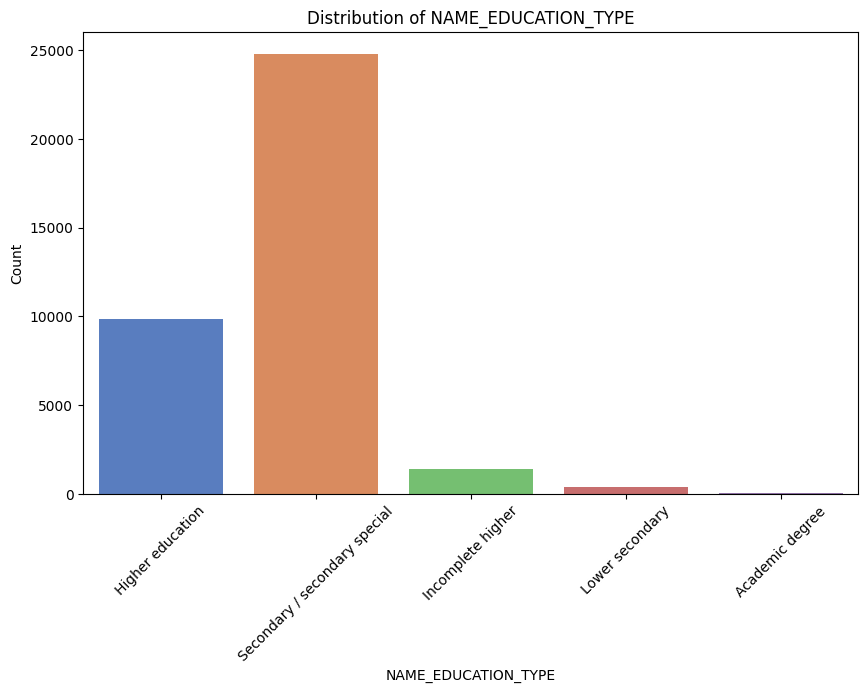

d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


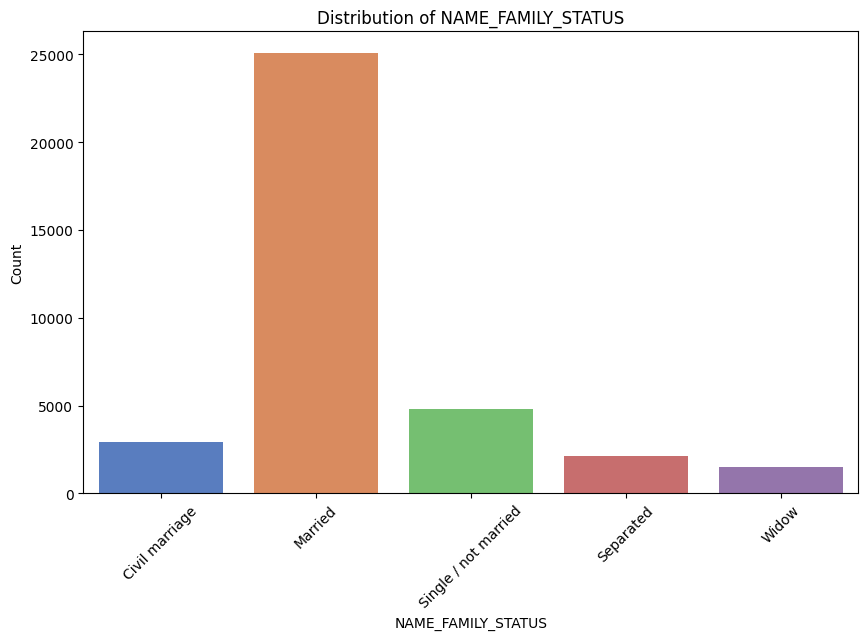

d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


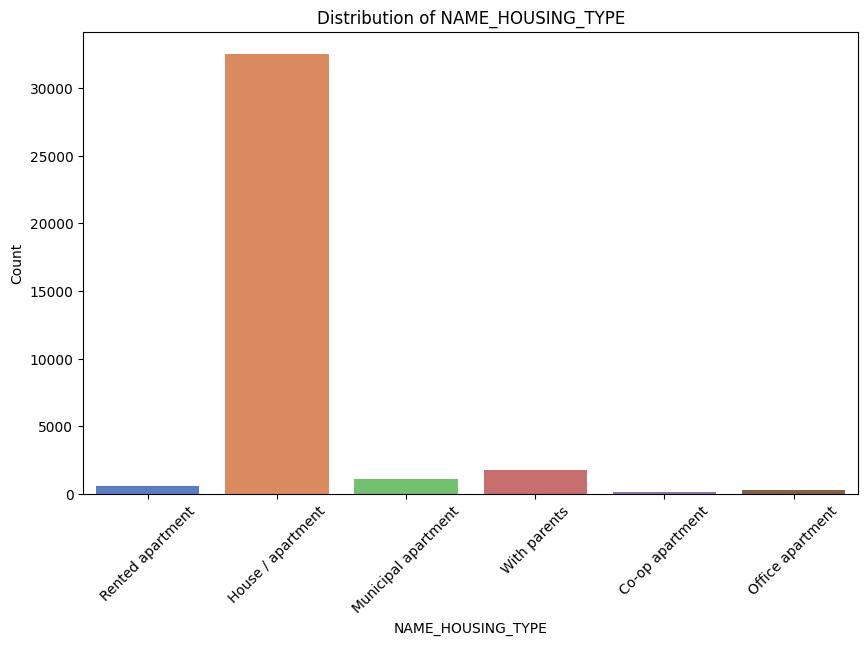

d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


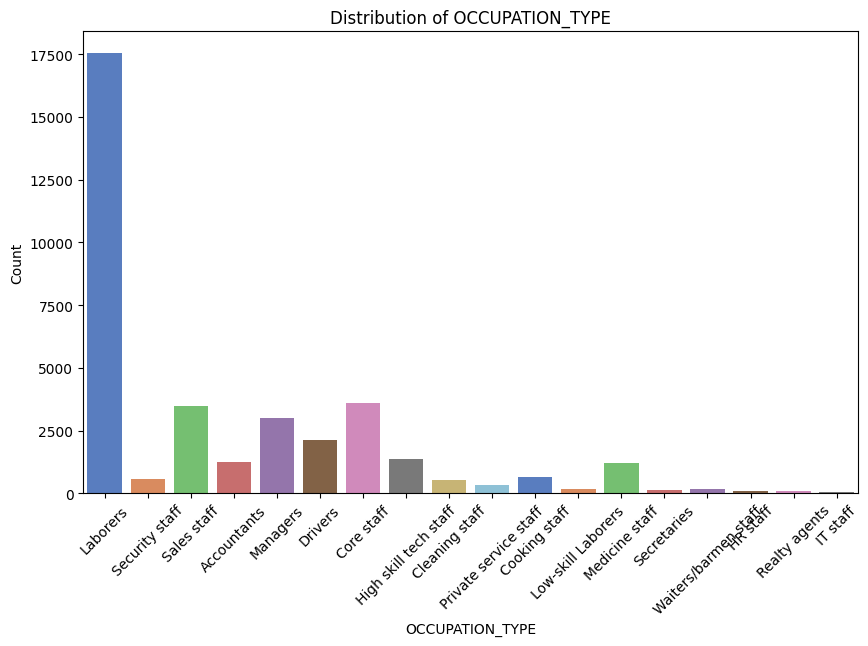

In [44]:
category_columns = merged_application_record.select_dtypes(include=["object"]).columns.tolist()

univariate_analyzer.set_strategy(CategoricalUnivariateAnalysis())
for col in category_columns:
    univariate_analyzer.execute_analysis(df=merged_application_record, feature=col)

<h5 style="color: Yellow">

- CODE_GENRE: Số lượng khách hàng nữ (F) cao hơn khách hàng nam (M)

- FLAG_OWN_CAR: Số lượng khách hàng không có xe chiếm ưu thế so với khách hàng có xe.

- FLAG_OWN_REALTY: Nhiều khách hàng có sở hữu bất động sản nhưng không quá lấn át nhóm không có bất động sản.

- NAME_HOUSING_TYPE: Phân bố có sự trên lệch rất lớn. Đại đa số khách hàng sống trong House / apartment. Các loại hình khác như Rented apartment hay With parents chiếm tỷ lệ rất nhỏ. <br>
  -> Có thể phân làm 3 nhóm như sau:

  +Nhóm 1: Các khách hàng đã sở hữu nhà riêng (House / apartment) <br>
  +Nhóm 2: Các khách hàng ở nhà thuê, trọ, nhà được người khác quản lý (Rented apartment, Municipal apartment, Co-op apartment, và Office apartment) <br>
  +Nhóm 3: Các khách hàng ở nhà cùng bố mẹ (With parents) <br>

- NAME_EDUCATION_TYPE: Phân bố có sự trên lệch rất lớn. Nhóm Secondary / secondary special chiếm ưu thế rõ rệt, kế tiếp là Higher education. Trong khi đó nhóm Academic degree lại có số lượng vô cùng thấp.
  -> Có thể gom nhóm Academic degree vào nhóm Higher education do có cùng tính chất là bậc cao học. Việc gom lại sẽ giúp mô hình không bị nhiễu với các giá trị có tần suất thấp.

- NAME_INCOME_TYPE: Phần lớn khách hàng thuộc nhóm Working (Đang đi làm). Nhóm Student có số lượng vô cùng thấp. <br>
  -> Có thể gom Student vào nhóm Working hoặc Commercial associate vì sinh viên đi làm thêm cũng có tính chất thu nhập tương đồng với nhóm đang lao động. Việc gom lại sẽ tránh gây nhiễu mô hình vì chỉ có rất ít các khách hàng là Student nhưng lỡ họ nợ xấu thì mô hình sẽ đánh giá toàn Student là đối tượng rủi ro.

- NAME_FAMILY_STATUS: Phần lớn khách hàng thuộc nhóm Married (Đã kết hôn). Các nhóm còn lại cũng phân bố ổn định không quá thấp.

- OCCUPATION_TYPE: Có rất nhiều giá trị khác nhau. Đa phần là Laborers (lao động phổ thông). Nhiều giá trị có tần xuất vô cùng thấp. <br>
-> Có thể gom các nhóm theo tính chất công việc như sao <br>
+Nhóm 1: Chuyên gia và quản lý (High-Level Professional): Managers, Accountants, Core staff, High skill tech staff, IT staff <br>
+Nhóm 2: Lao động kỹ thuật (Skilled Labor & Technical ): Drivers, Medicine staff, Private service staff, Realty agents, HR staff, Secretaries<br>
+Nhóm 3: Lao động phổ thông (General Laborers): Laborers (Giữ nguyên vì số lượng quá lớn), Low-skill Laborers<br>
+Nhóm 4: Dịch vụ và bán hàng (Service & Sales): Sales staff, Security staff, Cooking staff, Waiters/barmen staff, Cleaning staff <br>
</h5>


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


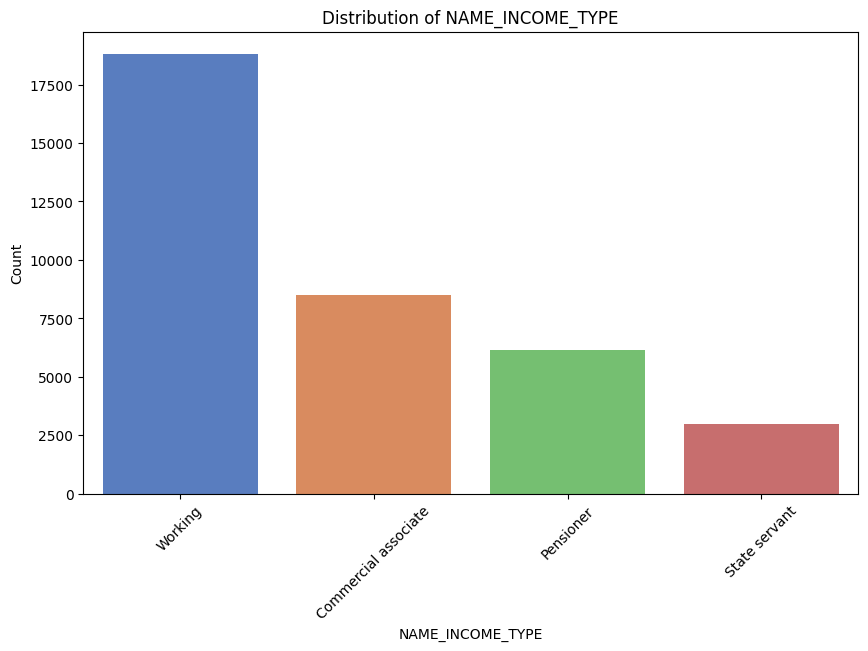

In [45]:
# Handle values having low frequency in NAME_INCOME_TYPE
merged_application_record["NAME_INCOME_TYPE"] = merged_application_record["NAME_INCOME_TYPE"].replace({"Student": "Working"})

# Visualize after handling
univariate_analyzer.execute_analysis(df=merged_application_record, feature="NAME_INCOME_TYPE")

d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


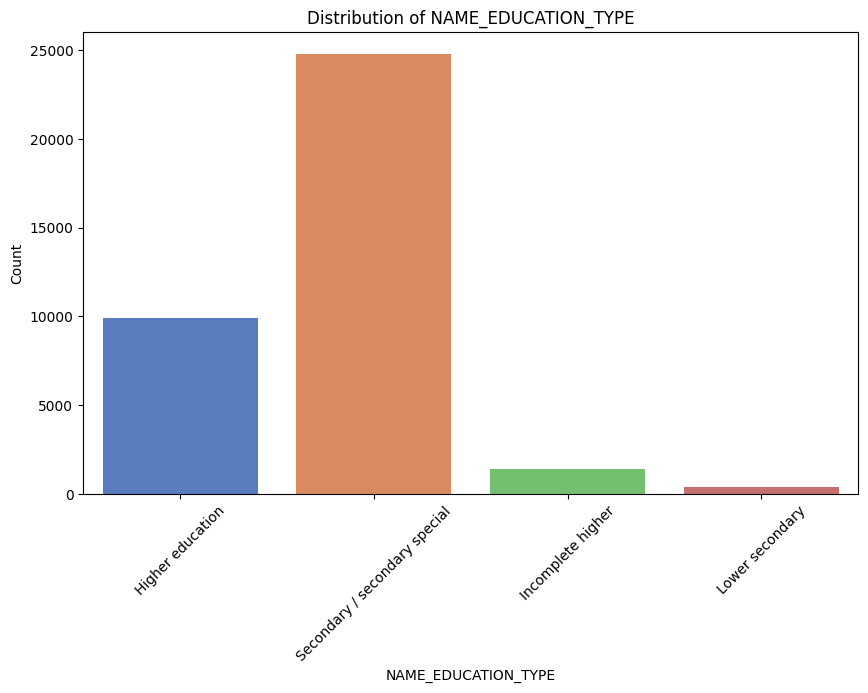

In [46]:
# Handle values having low frequency in NAME_EDUCATION_TYPE
merged_application_record["NAME_EDUCATION_TYPE"] = merged_application_record["NAME_EDUCATION_TYPE"].replace({"Academic degree": "Higher education"})

# Visualize after handling
univariate_analyzer.execute_analysis(df=merged_application_record, feature="NAME_EDUCATION_TYPE")

d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


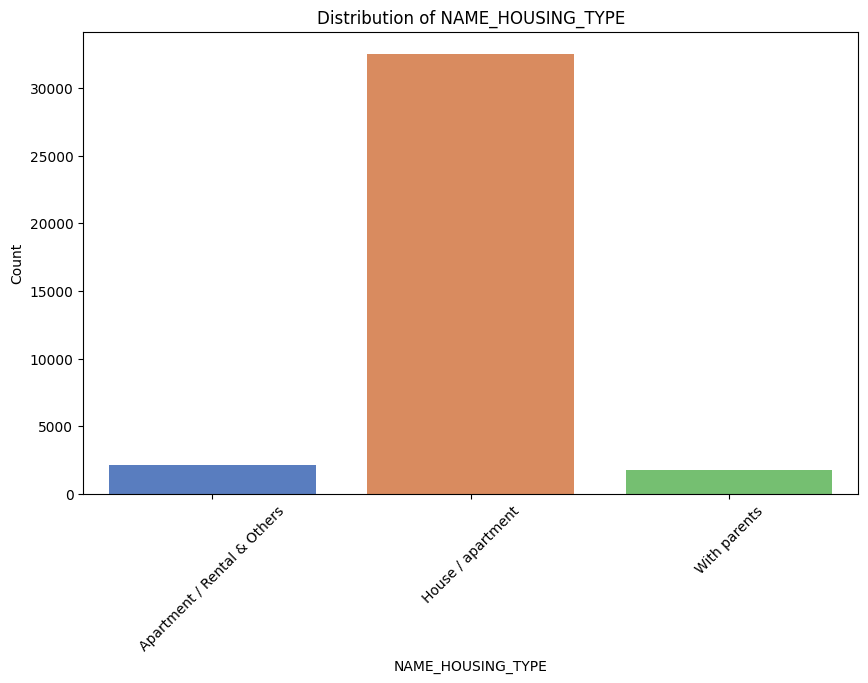

In [47]:
# Handle values having low frequency in NAME_HOUSING_TYPE
merged_application_record["NAME_HOUSING_TYPE"] = merged_application_record["NAME_HOUSING_TYPE"].apply(lambda x: "Apartment / Rental & Others" if x not in ["House / apartment", "With parents"] else x)

# Visualize after handling
univariate_analyzer.execute_analysis(df=merged_application_record, feature="NAME_HOUSING_TYPE")

d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


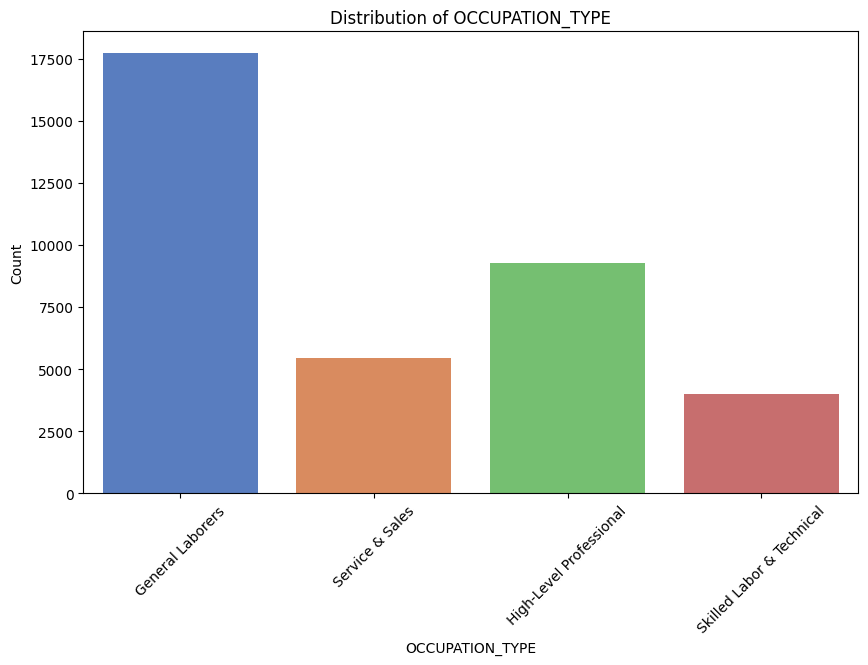

In [48]:
# Handle values having low frequency in OCCUPATION_TYPE
def cls_occupation_type(x):
    if x in ["Managers", "Accountants", "Core staff", "High skill tech staff", "IT staff"]:
        return "High-Level Professional"
    elif x in ["Drivers", "Medicine staff", "Private service staff", "Realty agents", "HR staff", "Secretaries"]:
        return "Skilled Labor & Technical"
    elif x in ["Laborers", "Low-skill Laborers"]:
        return "General Laborers"
    elif x in ["Sales staff", "Security staff", "Cooking staff", "Waiters/barmen staff", "Cleaning staff"]:
        return "Service & Sales"
    else:
        return "Others"

merged_application_record["OCCUPATION_TYPE"] = merged_application_record["OCCUPATION_TYPE"].apply(lambda x: cls_occupation_type(x))

# Visualize after handling
univariate_analyzer.execute_analysis(df=merged_application_record, feature="OCCUPATION_TYPE")

In [49]:
data_inspector.set_strategy(SummaryStatisticsInspectionStrategy())
data_inspector.execute_inspection(df=merged_application_record)


Summary Statistics (Numerical Features):
                 ID  AMT_INCOME_TOTAL  FLAG_WORK_PHONE    FLAG_PHONE  \
count  3.645700e+04      36457.000000     36457.000000  36457.000000   
mean   5.078227e+06     180580.802164         0.225526      0.294813   
std    4.187524e+04      79145.326680         0.417934      0.455965   
min    5.008804e+06      27000.000000         0.000000      0.000000   
25%    5.042028e+06     121500.000000         0.000000      0.000000   
50%    5.074614e+06     157500.000000         0.000000      0.000000   
75%    5.115396e+06     225000.000000         0.000000      1.000000   
max    5.150487e+06     360000.000000         1.000000      1.000000   

         FLAG_EMAIL        TARGET           AGE  YEARS_EMPLOYED  
count  36457.000000  36457.000000  36457.000000    36457.000000  
mean       0.089722      0.016897     43.260334        5.261294  
std        0.285787      0.128886     11.510414        5.343061  
min        0.000000      0.000000     20.0000

# **10. Bivariate Analysis**


## 10.1. Demographic vs Target


### 10.1.1. AGE - TARGET


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\bivariate_analysis.py:71: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='binned_' + feature1, y=feature2, data=df, ci=None)


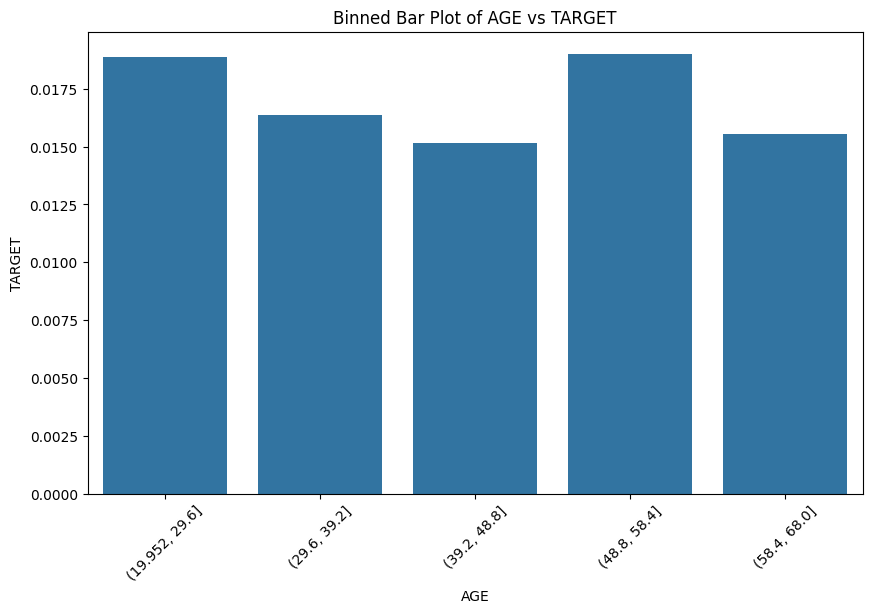

In [50]:
bivariate_analyzer = BivariateAnalyzer(NumericalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df=merged_application_record, feature1="AGE", feature2="TARGET", option="binned_bar_plot")

<h5 style="color: yellow">
Binned bar plot cho thấy nhóm tuổi từ (19.952 - 29.6] và (48.8 - 58.4] có tỷ lệ nợ xấu cao nhất
</h5>


Univariate Analyzing column: YEARS_EMPLOYED when Age:(19.952-29.6]


2026-01-26 08:02:21,447 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")
2026-01-26 08:02:21,455 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


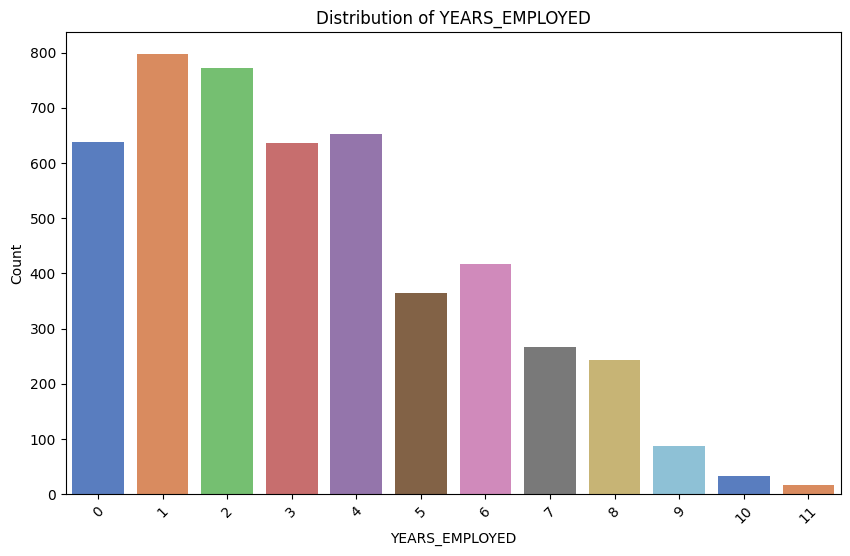

Univariate Analyzing column: YEARS_EMPLOYED when Age:(48.8-58.4]


2026-01-26 08:02:21,716 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")
2026-01-26 08:02:21,725 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


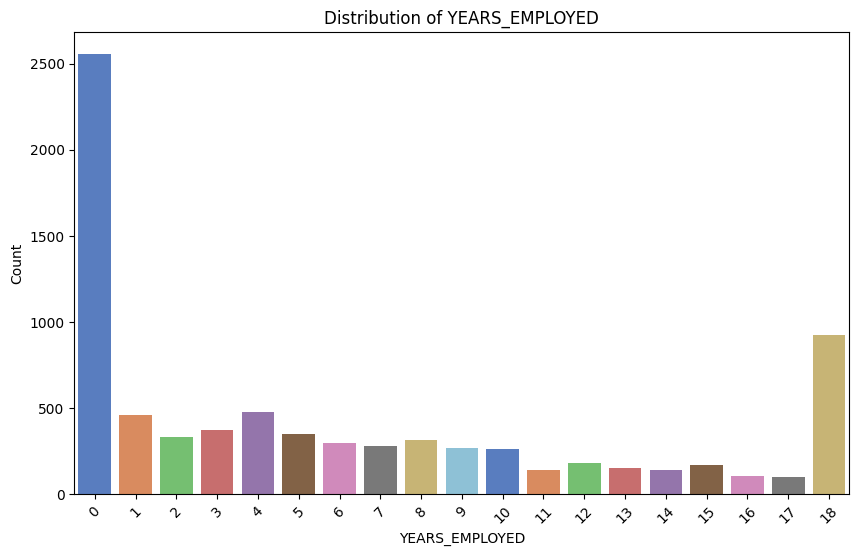

d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


Univariate Analyzing column: NAME_INCOME_TYPE when Age:(19.952-29.6]


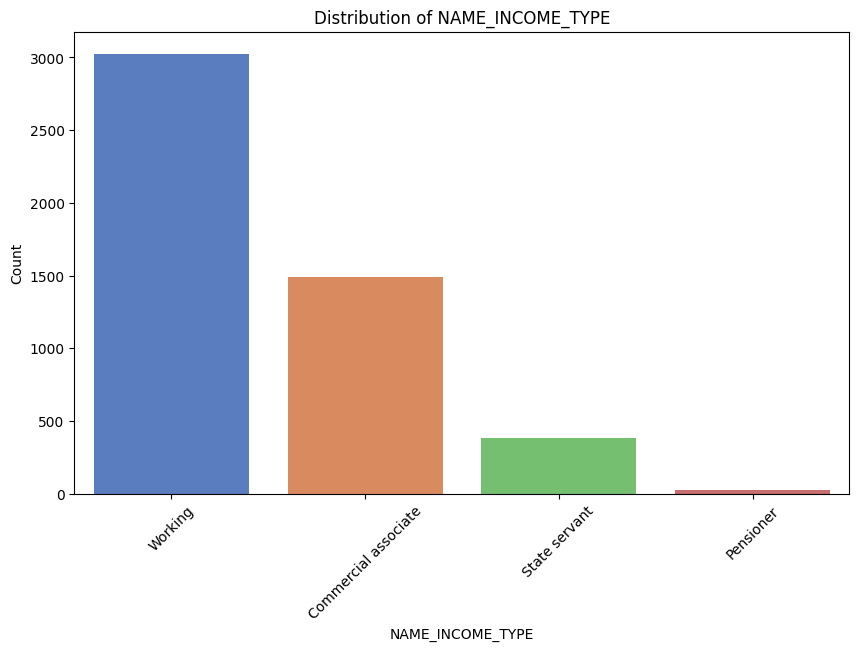

Univariate Analyzing column: NAME_INCOME_TYPE when Age:(48.8-58.4]


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


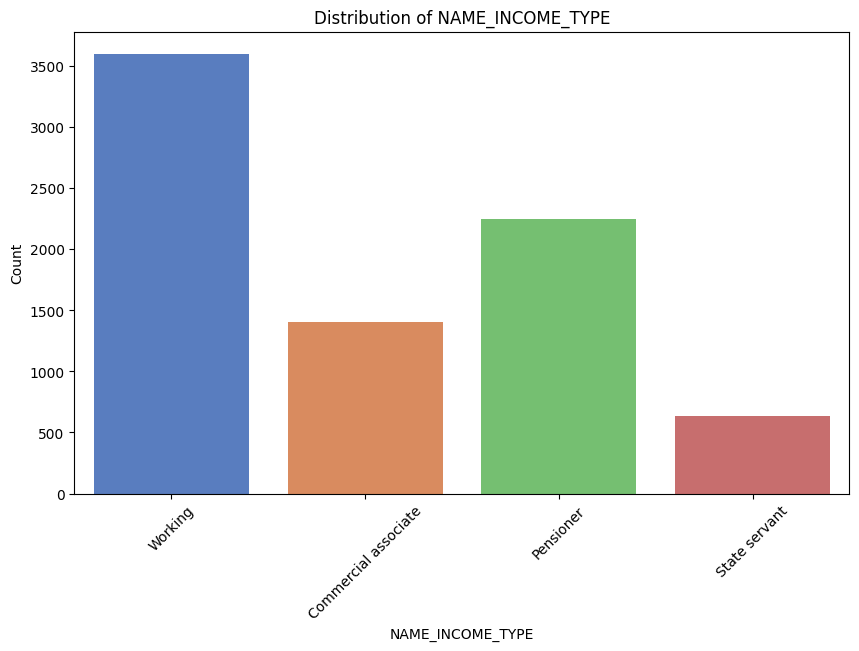

Univariate Analyzing column: NAME_HOUSING_TYPE when Age:(19.952-29.6]


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


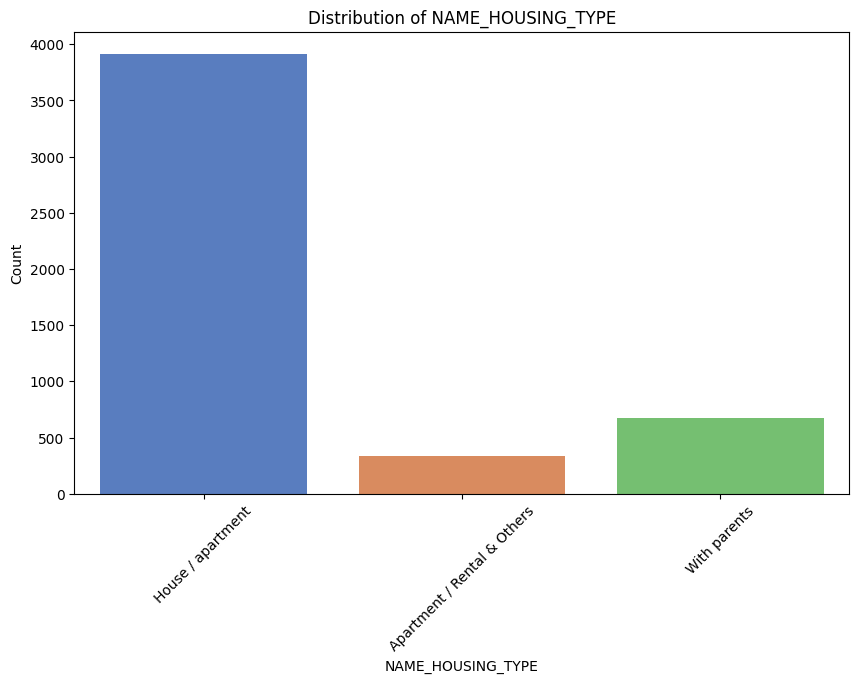

Univariate Analyzing column: NAME_HOUSING_TYPE when Age:(48.8-58.4]


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


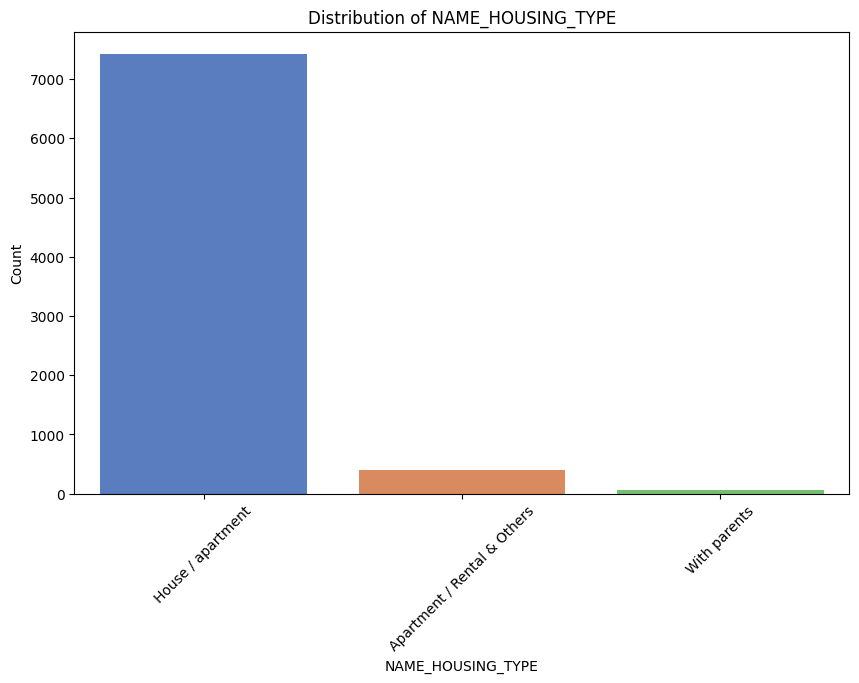

In [51]:
# Analyze high default rate in AGE bins
high_default_age_bin1 = merged_application_record[(merged_application_record["AGE"] > 19.952) & (merged_application_record["AGE"] <= 29.6)]
high_default_age_bin2 = merged_application_record[(merged_application_record["AGE"] > 48.8) & (merged_application_record["AGE"] <= 58.4)]
dfs = {"Age:(19.952-29.6]": high_default_age_bin1, "Age:(48.8-58.4]":high_default_age_bin2}
for col in ["YEARS_EMPLOYED", "NAME_INCOME_TYPE", "NAME_HOUSING_TYPE"]:
    for name, df in dfs.items():
        print(f"Univariate Analyzing column: {col} when {name}")
        univariate_analyzer.execute_analysis(df=df, feature=col)


<h5 style="color: yellow">
Nhóm Widow (Góa phụ) đa phần có kinh nghiệm làm việc = 0 và pensioner cho thấy chủ yếu là những người đã về hưu.
</h5>


In [52]:
merged_application_record.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'TARGET', 'AGE',
       'YEARS_EMPLOYED', 'CNT_CHILDREN_BINNED', 'CNT_FAM_MEMBERS_BINNED'],
      dtype='object')

### 10.1.2. NAME_FAMILY_STATUS - TARGET


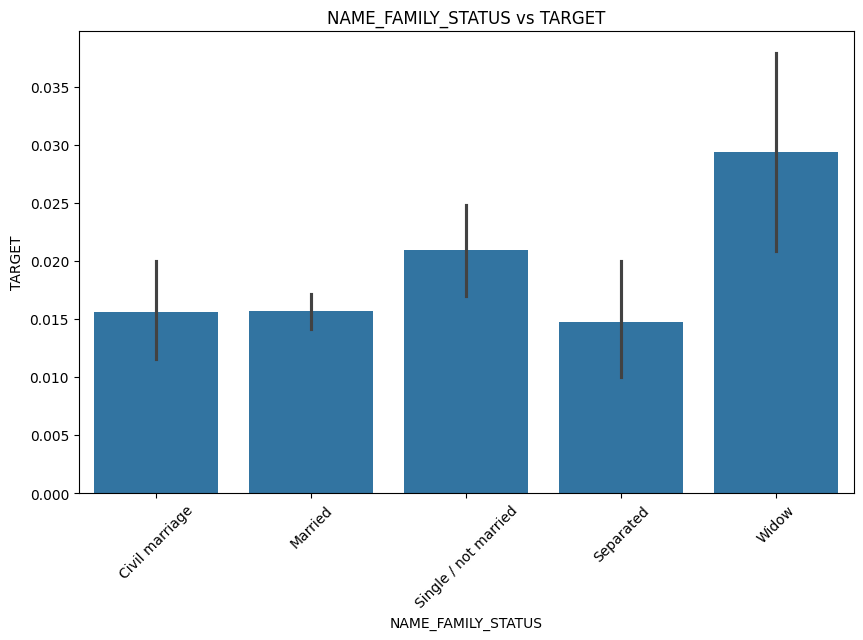

In [53]:
bivariate_analyzer.set_strategy(CategoricalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df=merged_application_record, feature1="NAME_FAMILY_STATUS", feature2="TARGET", option="column_chart")

<h5 style="color: yellow">
Nhóm Widow (Góa phụ) đang có tỷ lệ nợ xấu cao nhất (gần 0.03), tiếp theo là nhóm Single / not married. Điều này cho thấy những khách hàng đang phải gánh vác tài chính một mình có thể có rủi ro cao hơn so với nhóm Married (Kết hôn) – nhóm có tỷ lệ nợ xấu thấp và ổn định nhất.
</h5>


2026-01-26 08:02:22,639 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")
2026-01-26 08:02:22,645 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Univariate Analyzing column: YEARS_EMPLOYED when Family_Status:Widow


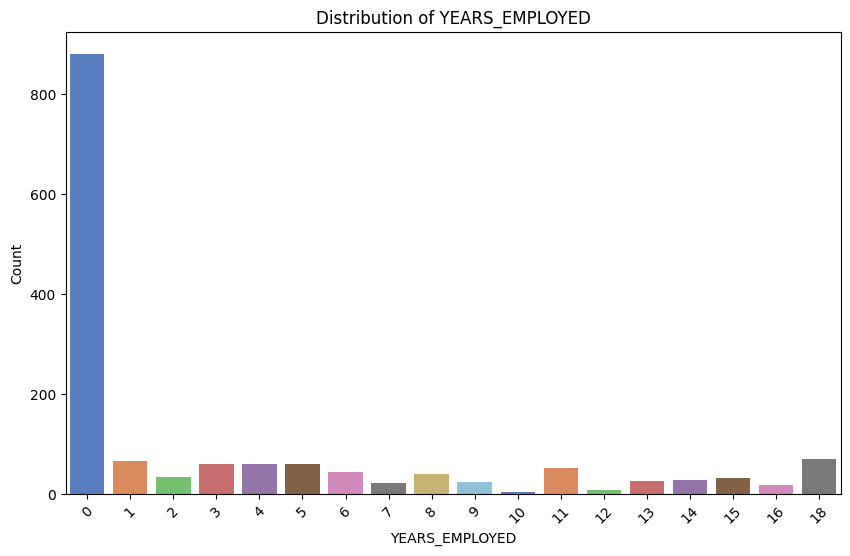

2026-01-26 08:02:22,792 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")
2026-01-26 08:02:22,800 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Univariate Analyzing column: YEARS_EMPLOYED when Family_Status:Single


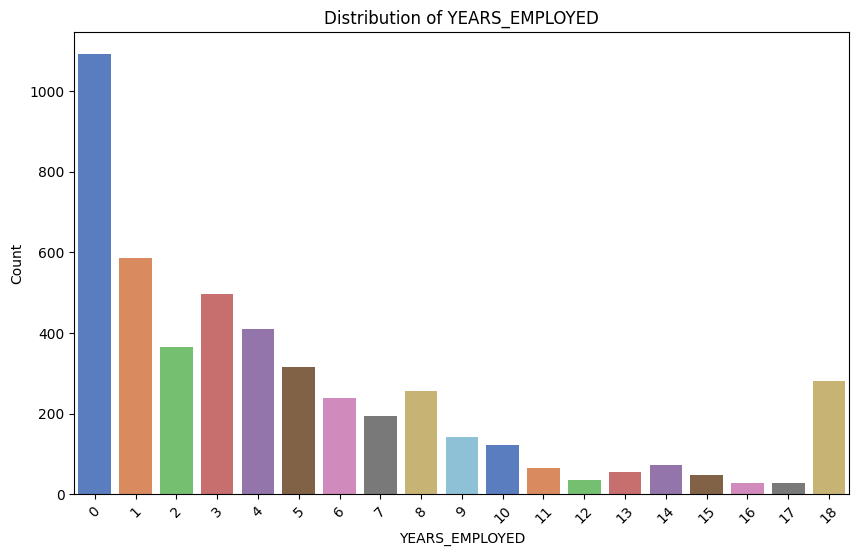

Univariate Analyzing column: NAME_INCOME_TYPE when Family_Status:Widow


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


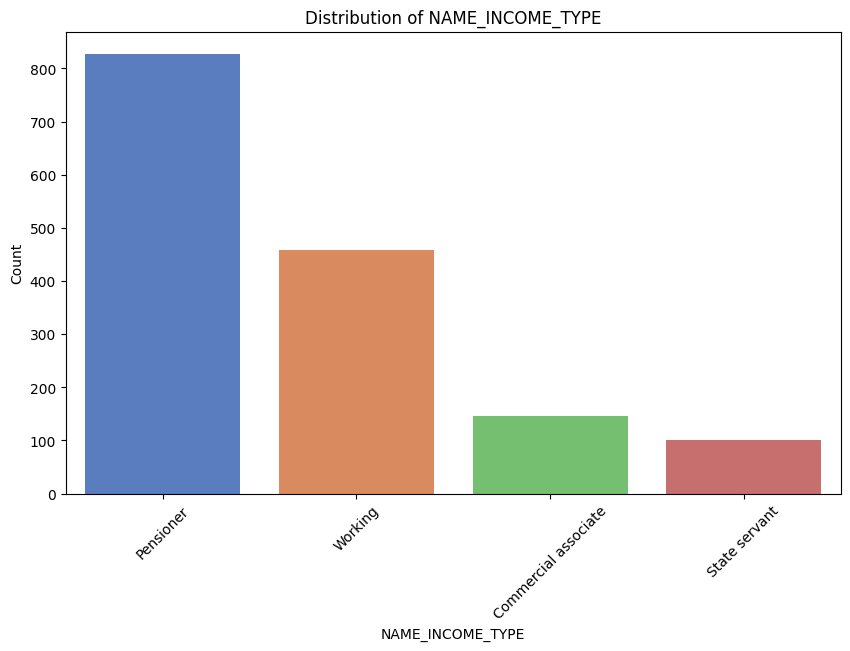

Univariate Analyzing column: NAME_INCOME_TYPE when Family_Status:Single


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


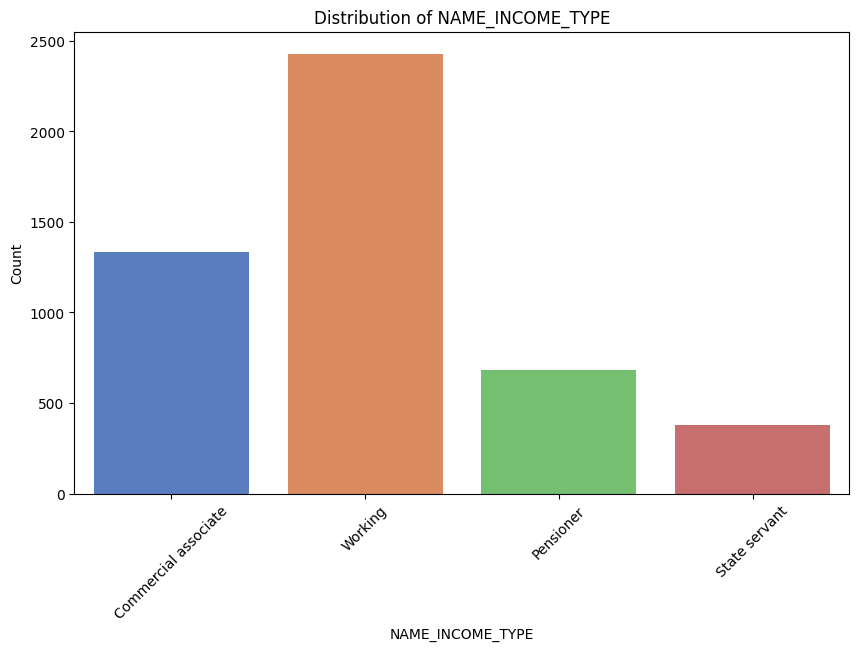

Univariate Analyzing column: NAME_HOUSING_TYPE when Family_Status:Widow


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


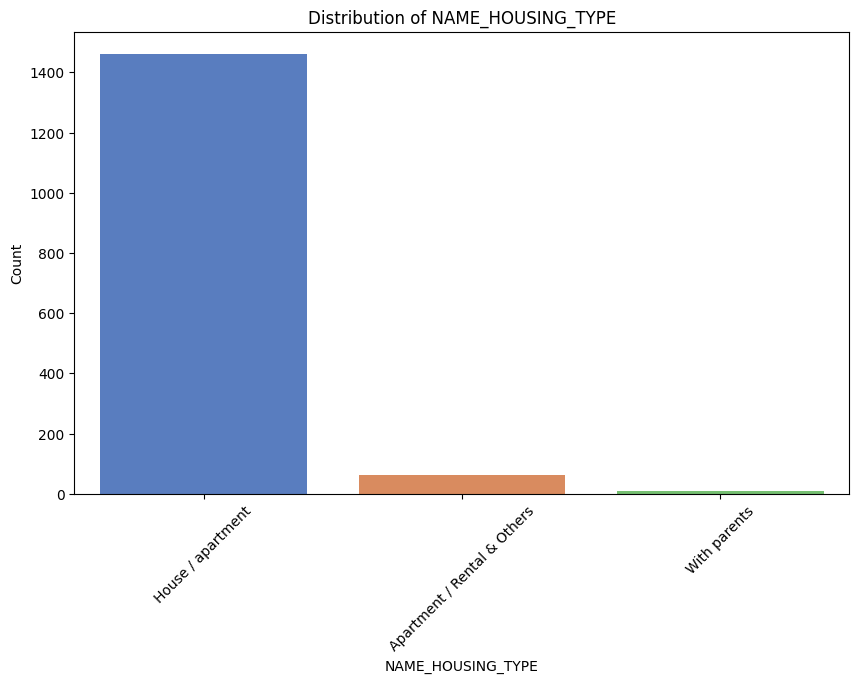

Univariate Analyzing column: NAME_HOUSING_TYPE when Family_Status:Single


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


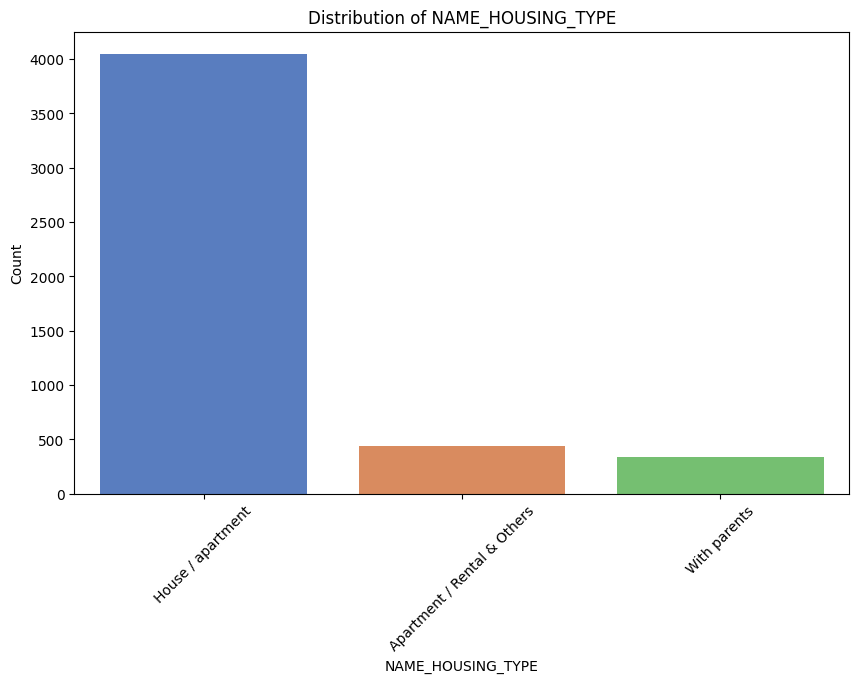

In [54]:
# Analyze high bad default rate in FAMILY_STATUS = 'Widow'
high_default_family_status_widow = merged_application_record[merged_application_record["NAME_FAMILY_STATUS"] == "Widow"]
high_default_family_status_single = merged_application_record[merged_application_record["NAME_FAMILY_STATUS"] == "Single / not married"]
dfs = {"Family_Status:Widow": high_default_family_status_widow, "Family_Status:Single": high_default_family_status_single}
for col in ["YEARS_EMPLOYED", "NAME_INCOME_TYPE", "NAME_HOUSING_TYPE"]:
    for name, df in dfs.items():
        print(f"Univariate Analyzing column: {col} when {name}")
        univariate_analyzer.execute_analysis(df=df, feature=col)

## 10.2. Financial ability vs Target


### 10.2.1. AMT_INCOME_TOTAL - TARGET


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\bivariate_analysis.py:71: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='binned_' + feature1, y=feature2, data=df, ci=None)


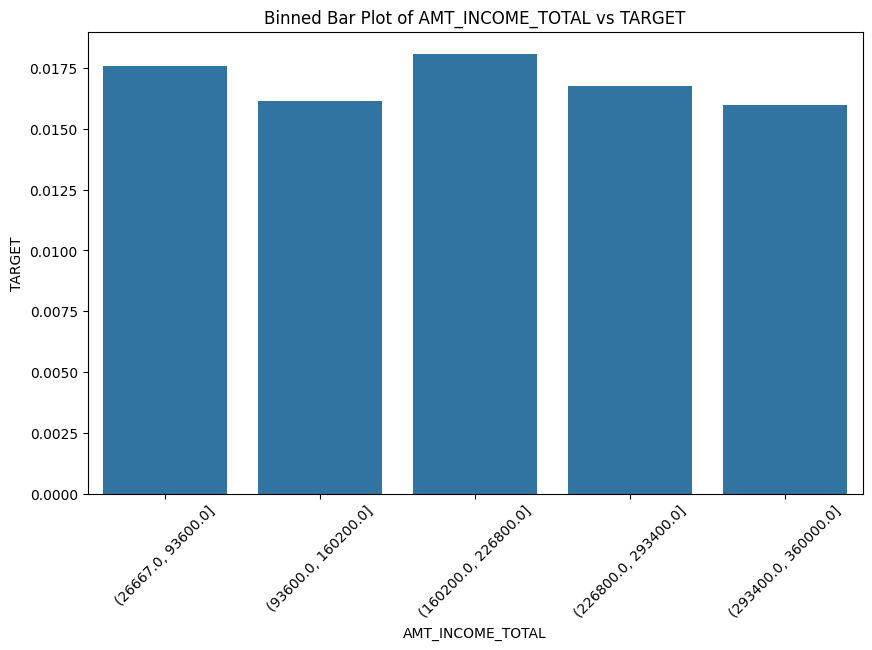

In [55]:
bivariate_analyzer.set_strategy(NumericalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df=merged_application_record, feature1="AMT_INCOME_TOTAL", feature2="TARGET", option="binned_bar_plot")

<h5 style="color:yellow">
Các nhóm (26667.0-936000.0] và (160200.0-226800.0] cho thấy tỷ lệ nợ xấu cao.
</h5>


2026-01-26 08:02:23,451 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")
2026-01-26 08:02:23,473 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Univariate Analyzing column: YEARS_EMPLOYED when Income:(26667.0-936000.0]


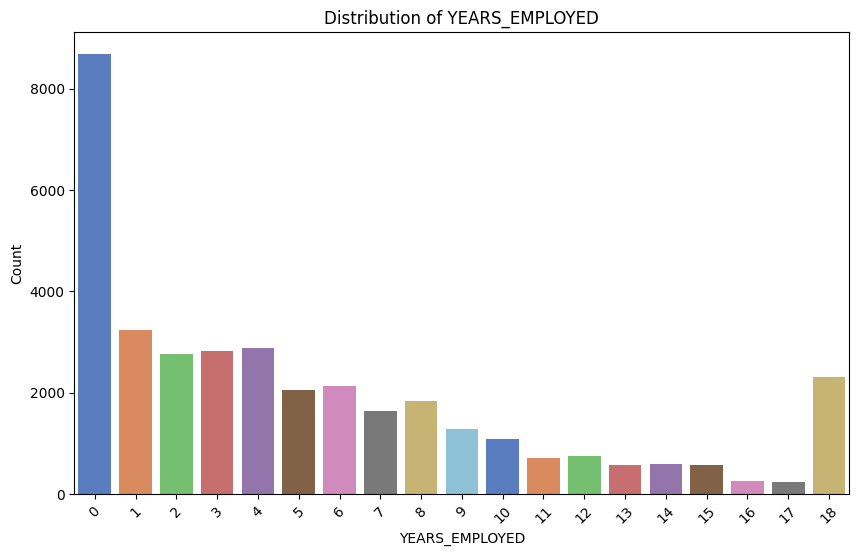

2026-01-26 08:02:23,625 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Univariate Analyzing column: YEARS_EMPLOYED when Income:(160200.0-226800.0]


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")
2026-01-26 08:02:23,636 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


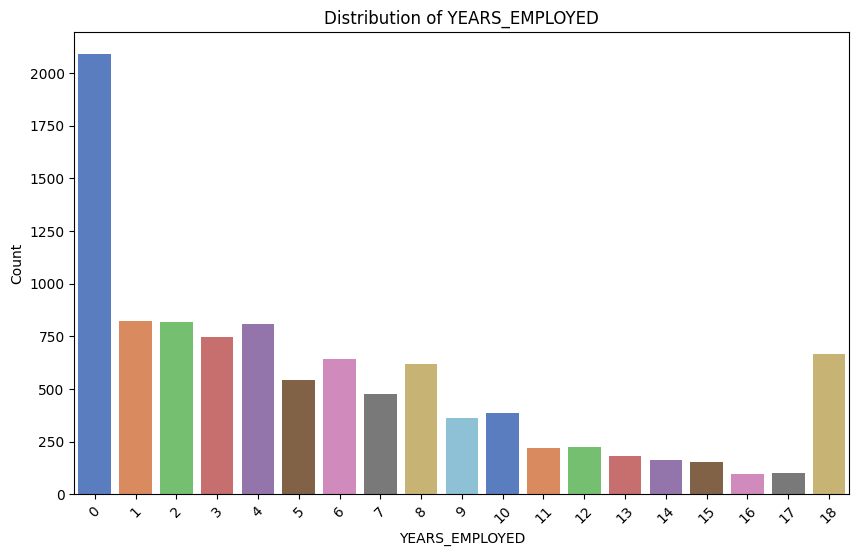

Univariate Analyzing column: NAME_INCOME_TYPE when Income:(26667.0-936000.0]


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


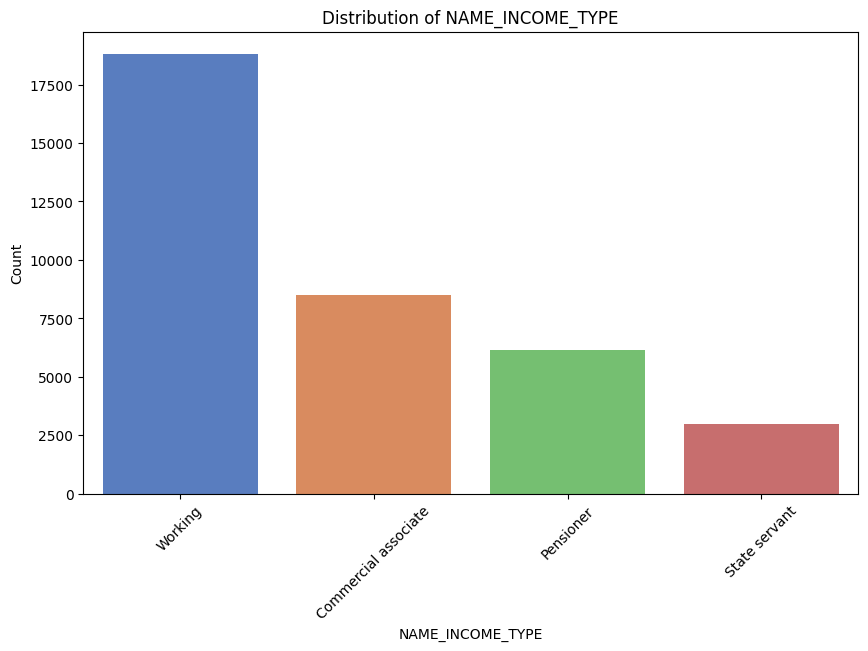

Univariate Analyzing column: NAME_INCOME_TYPE when Income:(160200.0-226800.0]


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


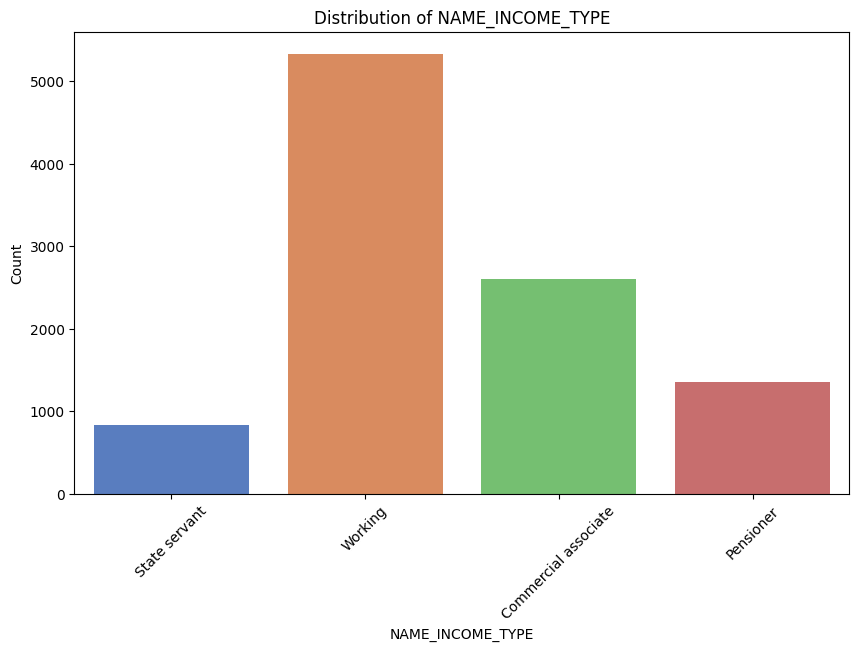

Univariate Analyzing column: NAME_HOUSING_TYPE when Income:(26667.0-936000.0]


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


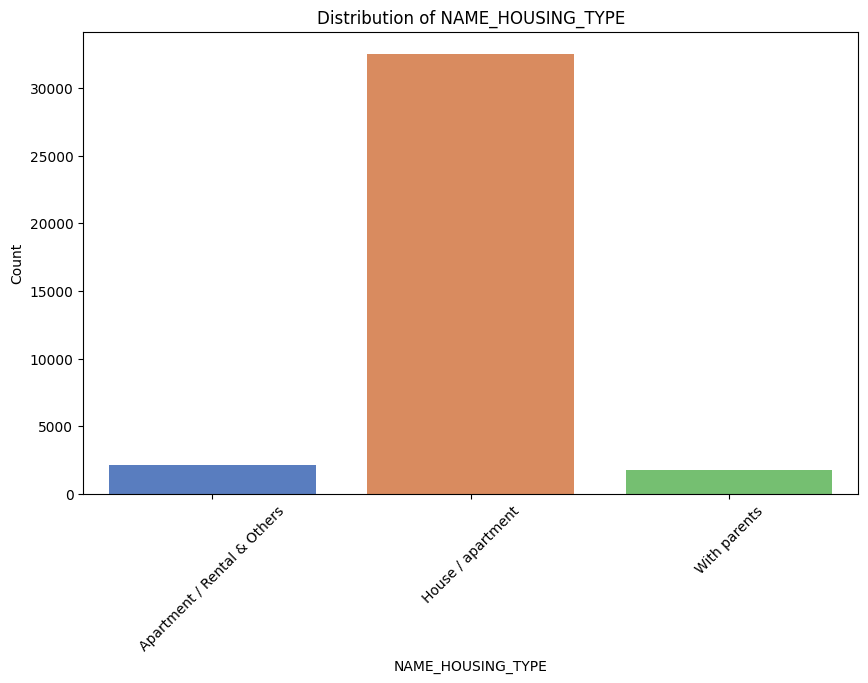

Univariate Analyzing column: NAME_HOUSING_TYPE when Income:(160200.0-226800.0]


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


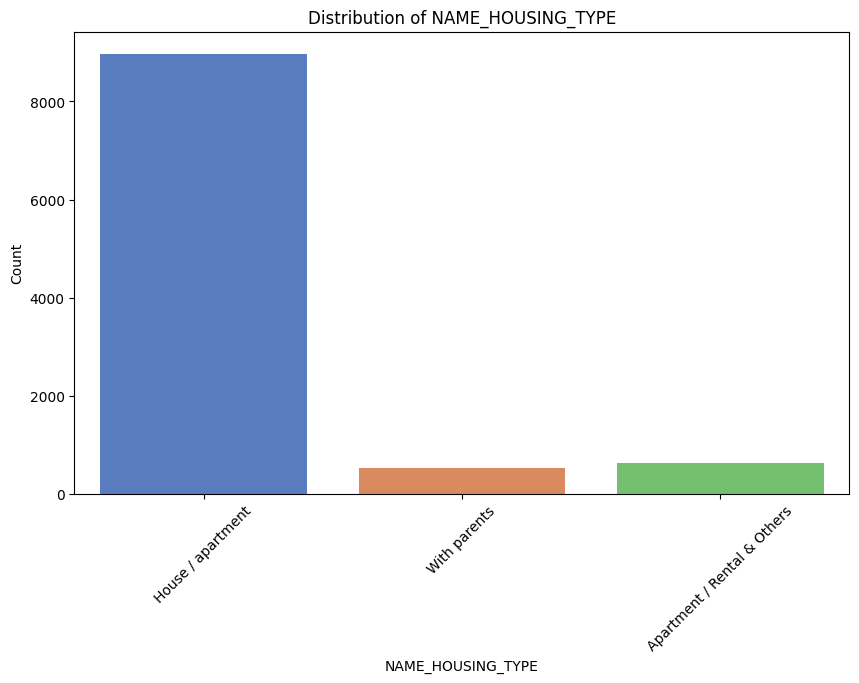

In [56]:
# Analyze high bad default rate in Income bins
high_default_income_bin1 = merged_application_record[(merged_application_record["AMT_INCOME_TOTAL"] > 26667.0) & (merged_application_record["AMT_INCOME_TOTAL"] <= 936000.0)]
high_default_income_bin2 = merged_application_record[(merged_application_record["AMT_INCOME_TOTAL"] > 160200.0) & (merged_application_record["AMT_INCOME_TOTAL"] <= 226800.0)]
dfs = {"Income:(26667.0-936000.0]": high_default_income_bin1, "Income:(160200.0-226800.0]": high_default_income_bin2}
for col in ["YEARS_EMPLOYED", "NAME_INCOME_TYPE", "NAME_HOUSING_TYPE"]:
    for name, df in dfs.items():
        print(f"Univariate Analyzing column: {col} when {name}")
        univariate_analyzer.execute_analysis(df=df, feature=col)

### 10.2.2. NAME_INCOME_TYPE - TARGET


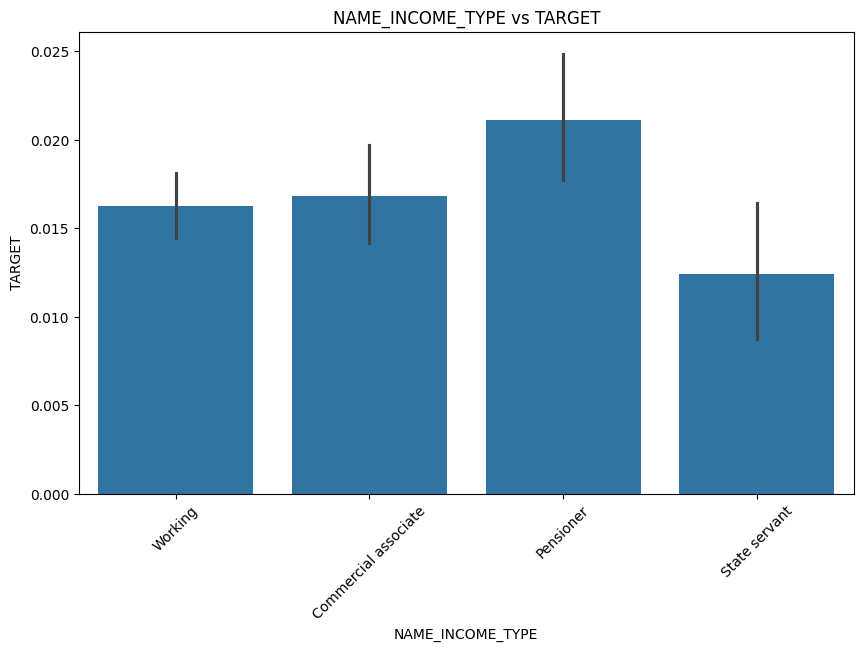

In [57]:
bivariate_analyzer.set_strategy(CategoricalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df=merged_application_record, feature1="NAME_INCOME_TYPE", feature2="TARGET", option="column_chart")

<h5 style="color:yellow">
Nhóm Pensioner (Người nghỉ hưu) có tỷ lệ nợ xấu cao nhất (hơn 0.02). Nhóm State servant (Công chức) có tỷ lệ nợ xấu thấp nhất, cho thấy tính ổn định của công việc nhà nước giúp đảm bảo khả năng trả nợ tốt hơn.
</h5>


Univariate Analyzing column: CODE_GENDER when Income_Type:Pensioner


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


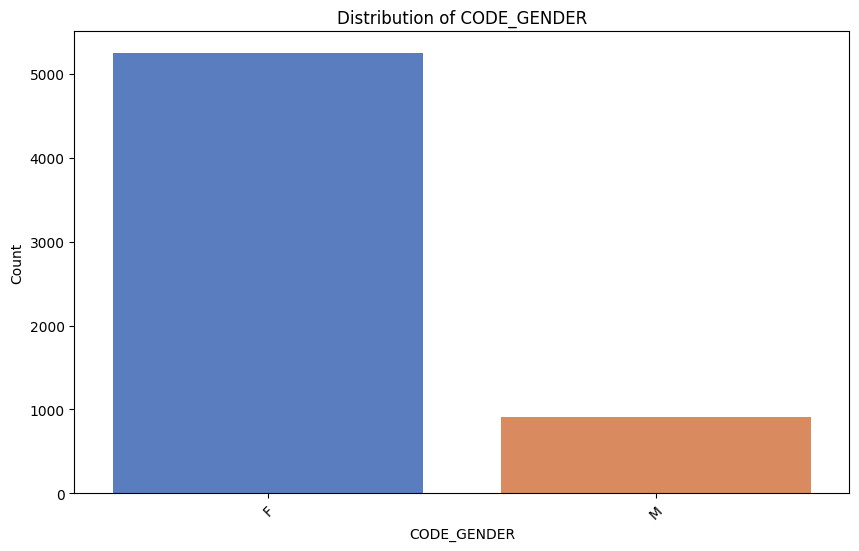

Univariate Analyzing column: FLAG_OWN_CAR when Income_Type:Pensioner


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


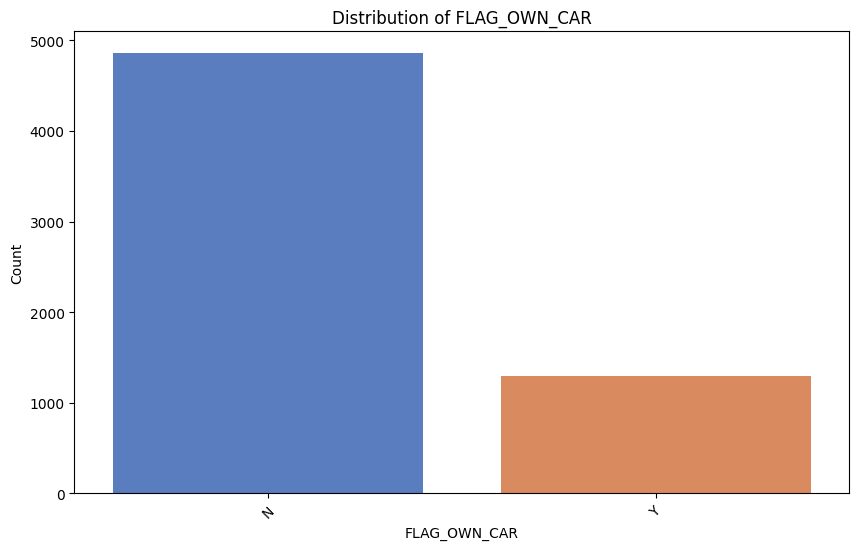

Univariate Analyzing column: FLAG_OWN_REALTY when Income_Type:Pensioner


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


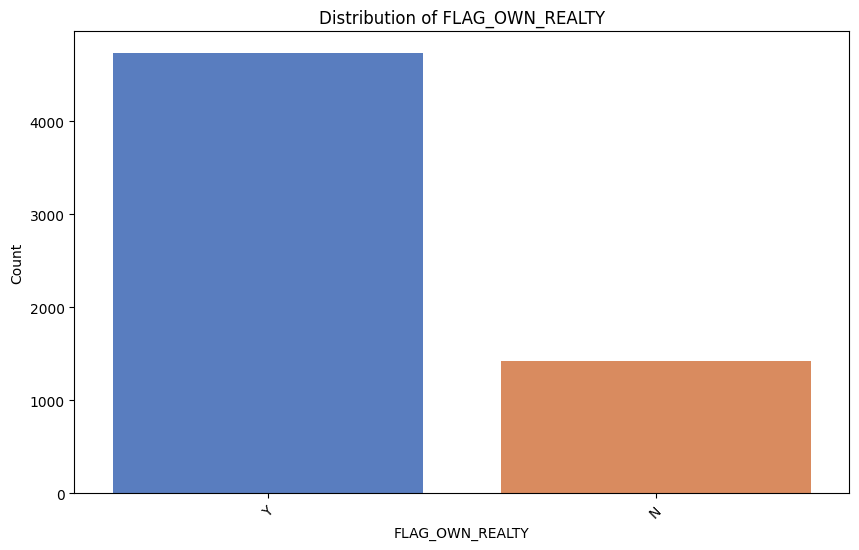

Univariate Analyzing column: NAME_INCOME_TYPE when Income_Type:Pensioner


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


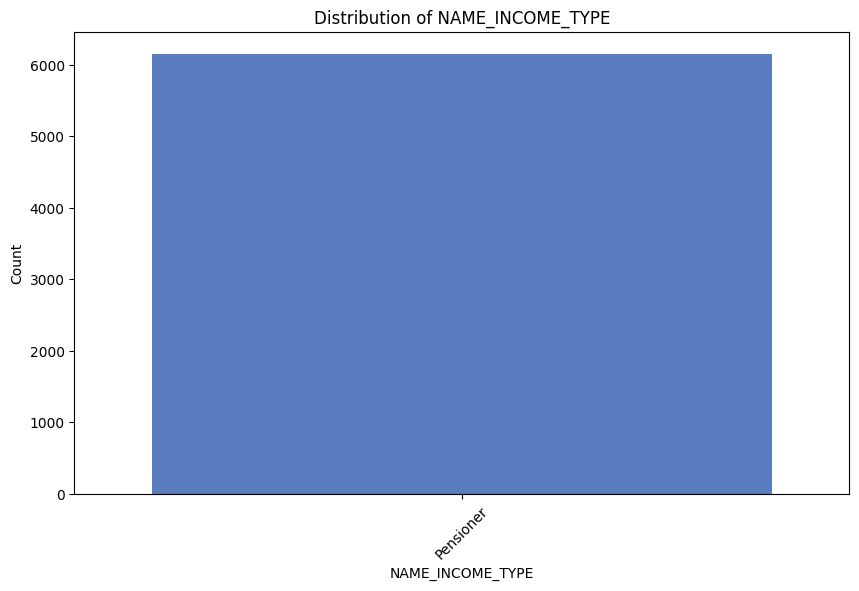

Univariate Analyzing column: NAME_EDUCATION_TYPE when Income_Type:Pensioner


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


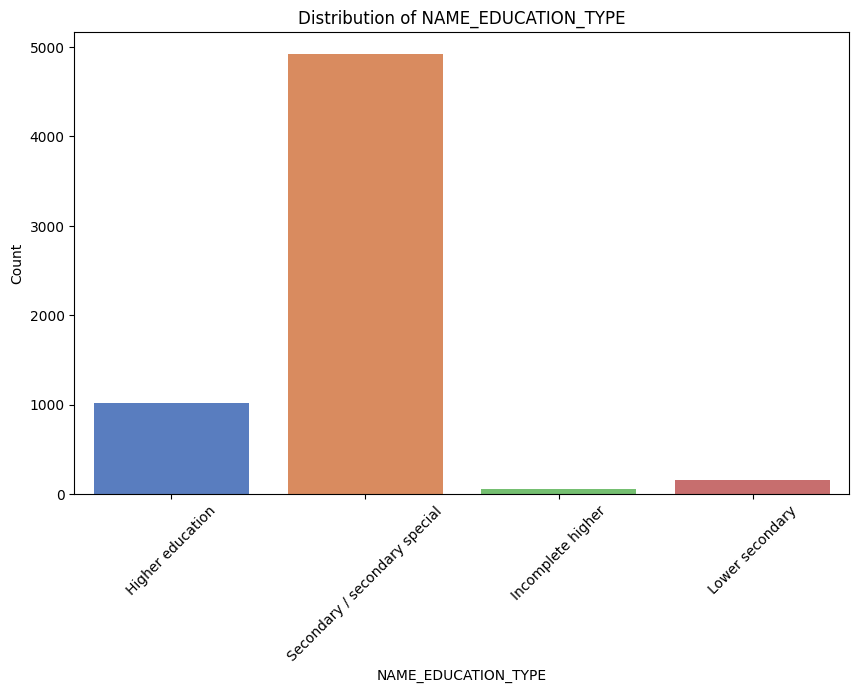

Univariate Analyzing column: NAME_FAMILY_STATUS when Income_Type:Pensioner


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


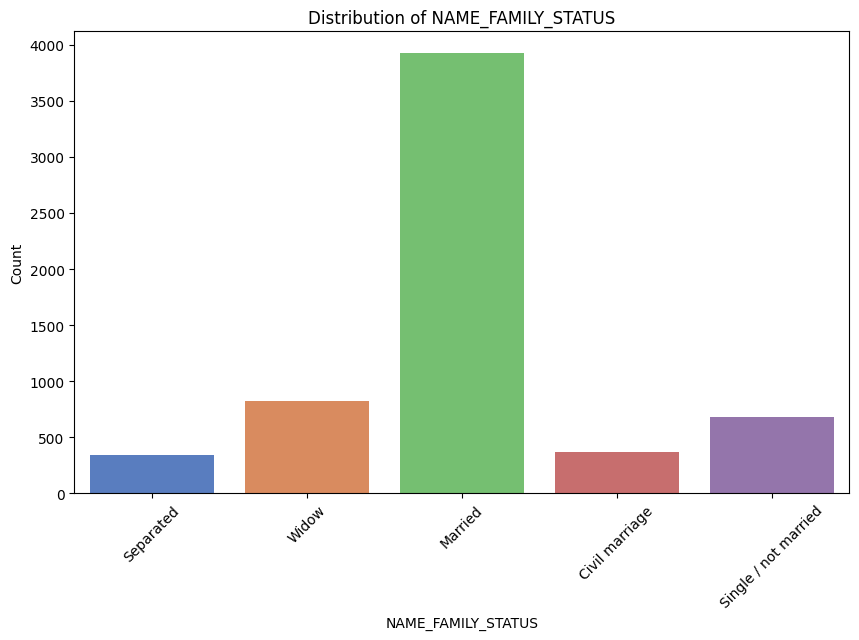

Univariate Analyzing column: NAME_HOUSING_TYPE when Income_Type:Pensioner


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


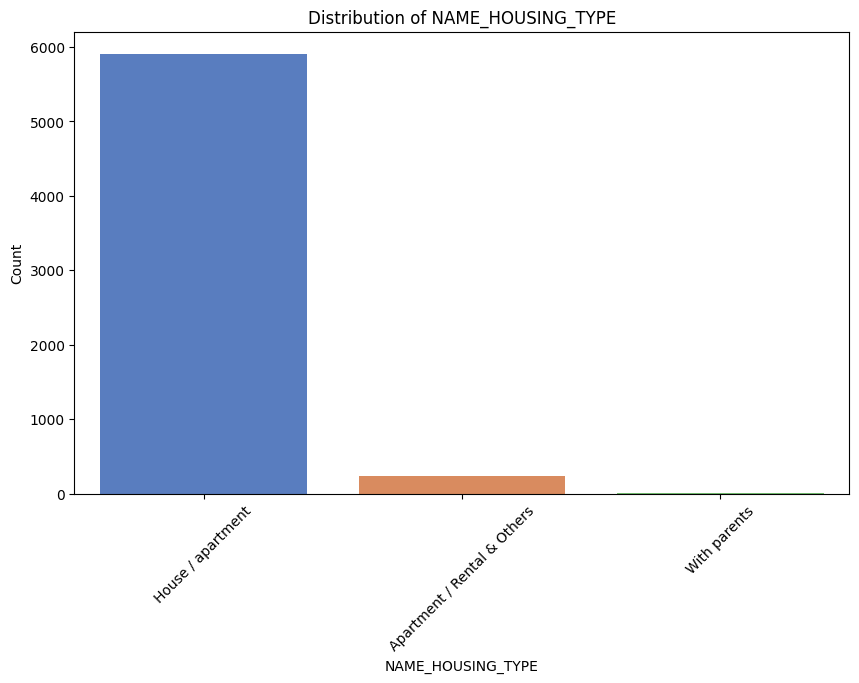

Univariate Analyzing column: OCCUPATION_TYPE when Income_Type:Pensioner


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


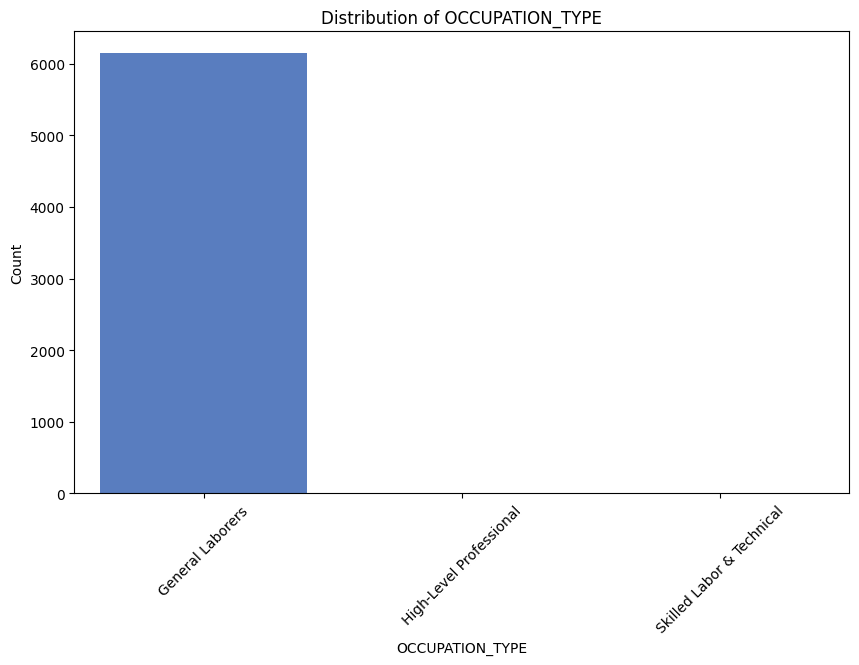

In [58]:
# Analyze high bad default rate in NAME_INCOME_TYPE = 'Pensioner'
high_default_income_type_pensioner = merged_application_record[merged_application_record["NAME_INCOME_TYPE"] == "Pensioner"]
dfs = {"Income_Type:Pensioner": high_default_income_type_pensioner}
for col in merged_application_record.select_dtypes(include=["object"]).columns.tolist():
    for name, df in dfs.items():
        print(f"Univariate Analyzing column: {col} when {name}")
        univariate_analyzer.execute_analysis(df=df, feature=col)

## 10.3. Occupation & Experience vs Target


### 10.3.1. OCCUPATION_TYPE - TARGET


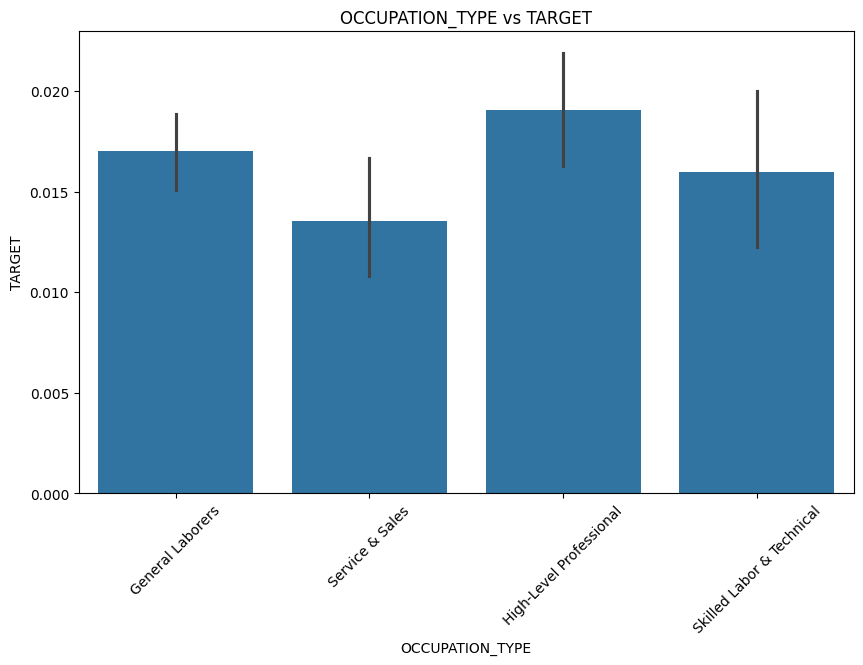

In [59]:
bivariate_analyzer.set_strategy(CategoricalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df=merged_application_record, feature1="OCCUPATION_TYPE", feature2="TARGET", option="column_chart")

<h5 style="color:yellow">
Nhóm High-Level Professional có tỷ lệ nợ xấu cao nhất trong biểu đồ này (vượt mức 0.015).
Đây là một insight ngược với suy nghĩ thông thường. Nhóm này có thu nhập cao nhưng có thể sở hữu nhiều khoản vay hoặc chi tiêu lớn hơn dẫn đến tỷ lệ nợ xấu vượt trội so với các nhóm còn lại.
</h5>


### 10.3.2. YEARS_EMPLOYED - TARGET


In [60]:
merged_application_record["YEARS_EMPLOYED"].describe()

count    36457.000000
mean         5.261294
std          5.343061
min          0.000000
25%          1.000000
50%          4.000000
75%          8.000000
max         18.000000
Name: YEARS_EMPLOYED, dtype: float64

d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\bivariate_analysis.py:71: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='binned_' + feature1, y=feature2, data=df, ci=None)


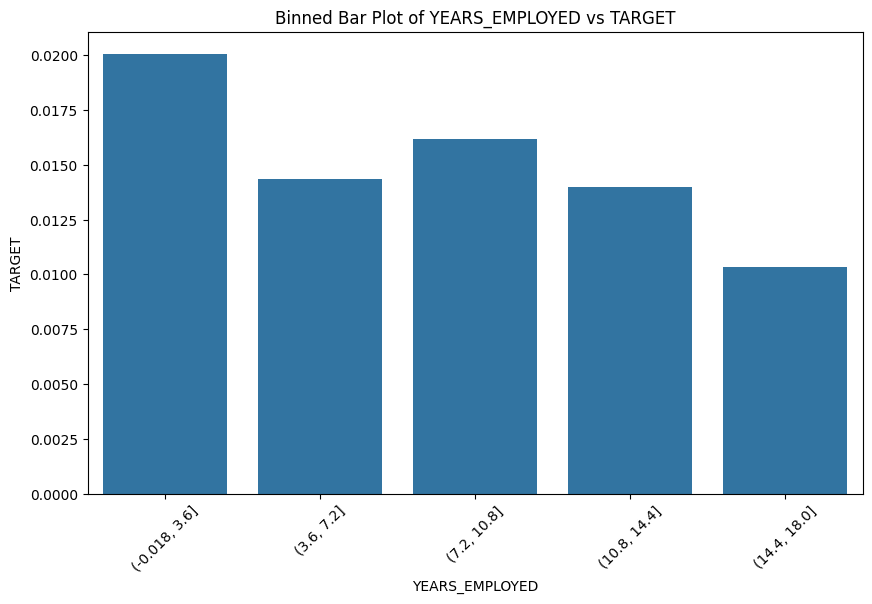

In [61]:
bivariate_analyzer.set_strategy(NumericalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df=merged_application_record, feature1="YEARS_EMPLOYED", feature2="TARGET", option="binned_bar_plot")

<h5 style="color:yellow">
Nhóm có từ 3.6 kinh nghiệm trở xuống có tỷ lệ nợ xấu cao nhất.
</h5>


### 10.3.3. NAME_EDUCATION_TYPE - TARGET


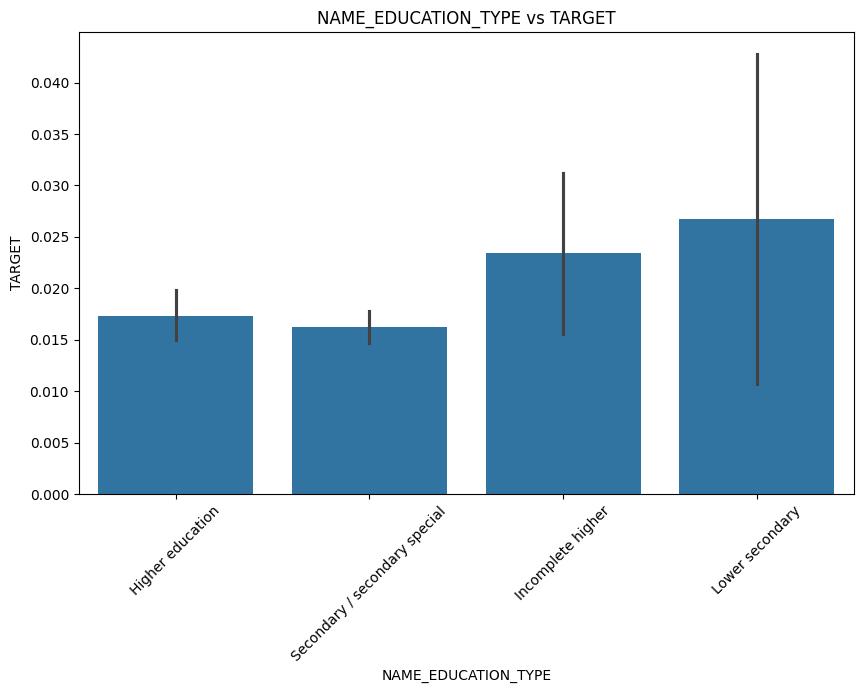

In [62]:
bivariate_analyzer.set_strategy(CategoricalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df=merged_application_record, feature1="NAME_EDUCATION_TYPE", feature2="TARGET", option="column_chart")

2026-01-26 08:02:26,076 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")
2026-01-26 08:02:26,082 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Univariate Analyzing column: YEARS_EMPLOYED when Education_Type:Lower secondary


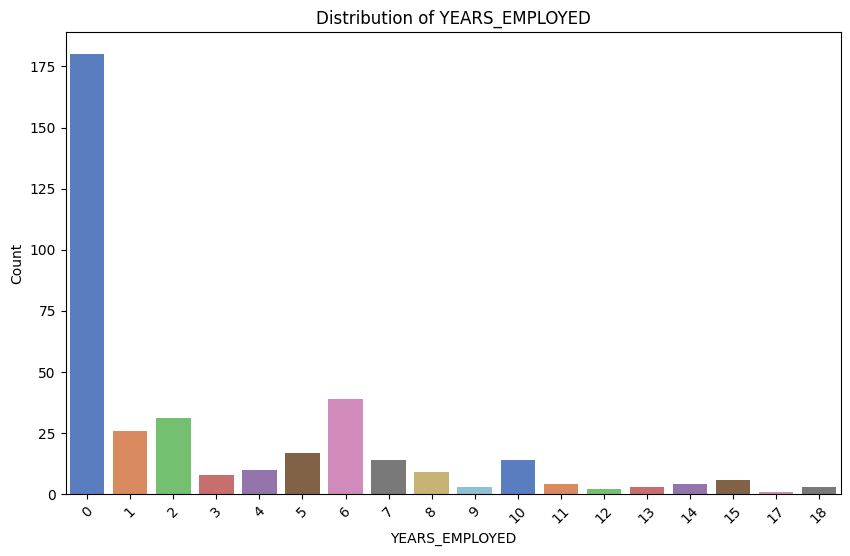

2026-01-26 08:02:26,226 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")
2026-01-26 08:02:26,231 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Univariate Analyzing column: YEARS_EMPLOYED when Education_Type:Incomplete higher


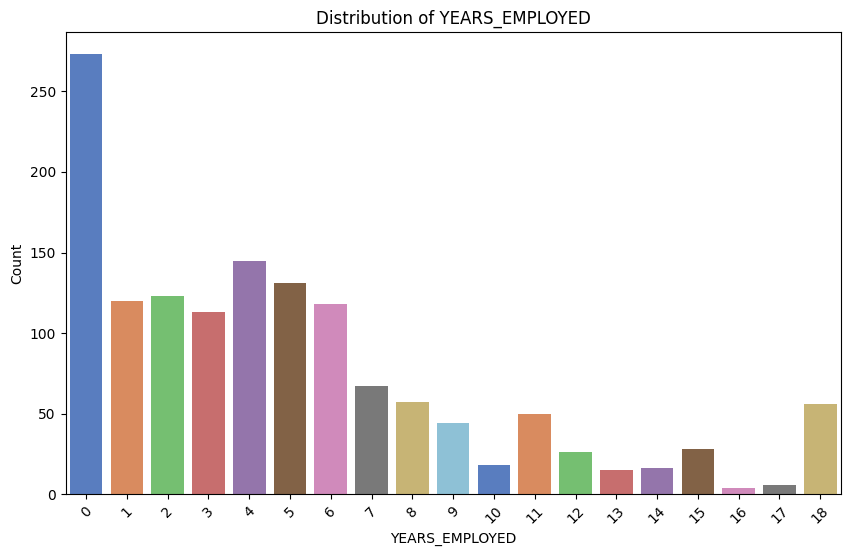

Univariate Analyzing column: NAME_INCOME_TYPE when Education_Type:Lower secondary


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


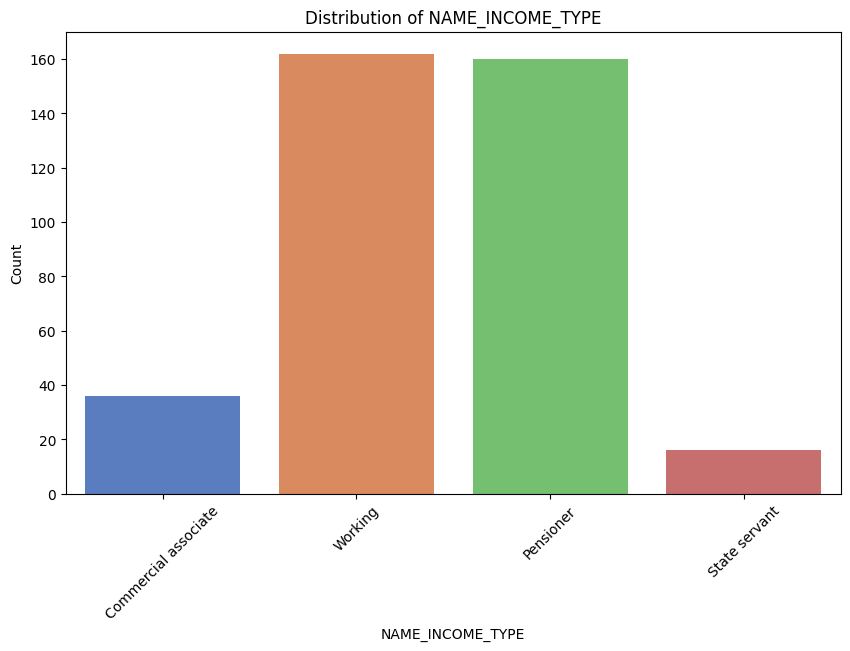

Univariate Analyzing column: NAME_INCOME_TYPE when Education_Type:Incomplete higher


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


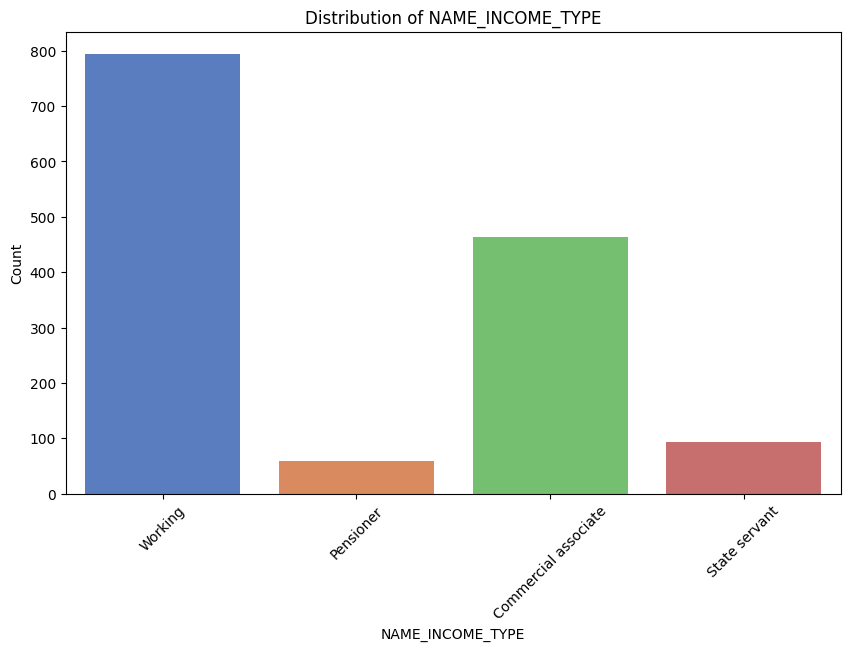

Univariate Analyzing column: NAME_HOUSING_TYPE when Education_Type:Lower secondary


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


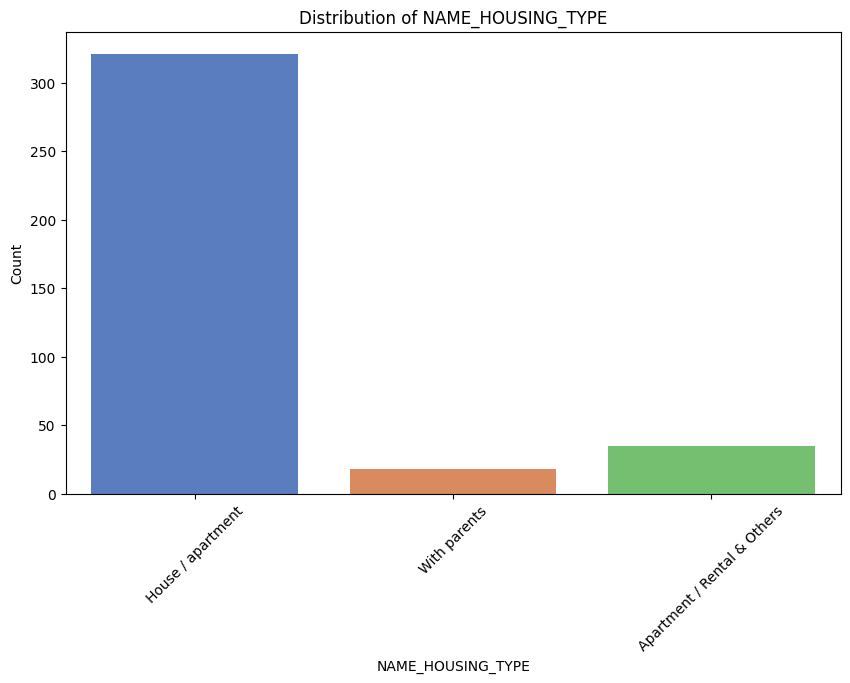

Univariate Analyzing column: NAME_HOUSING_TYPE when Education_Type:Incomplete higher


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


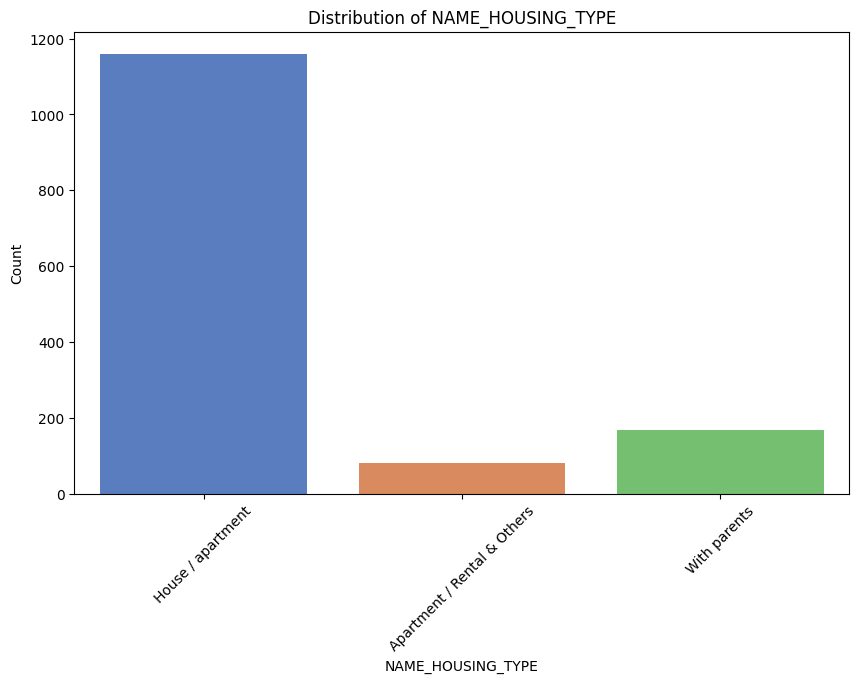

Univariate Analyzing column: OCCUPATION_TYPE when Education_Type:Lower secondary


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


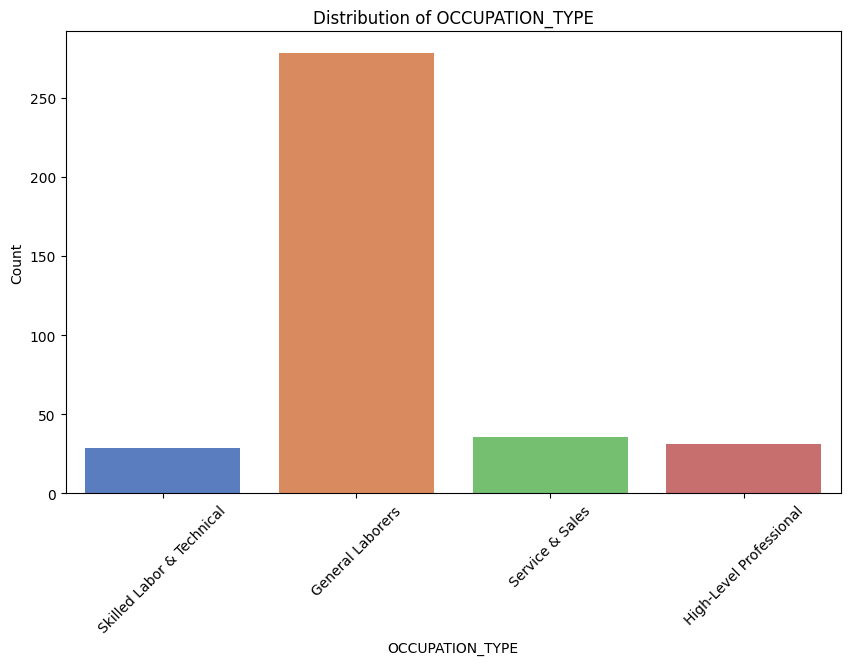

Univariate Analyzing column: OCCUPATION_TYPE when Education_Type:Incomplete higher


d:\dai_hoc\nam3\HK5\ADV_02\capstone_cuoi_khoa\code\analysis_functions\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


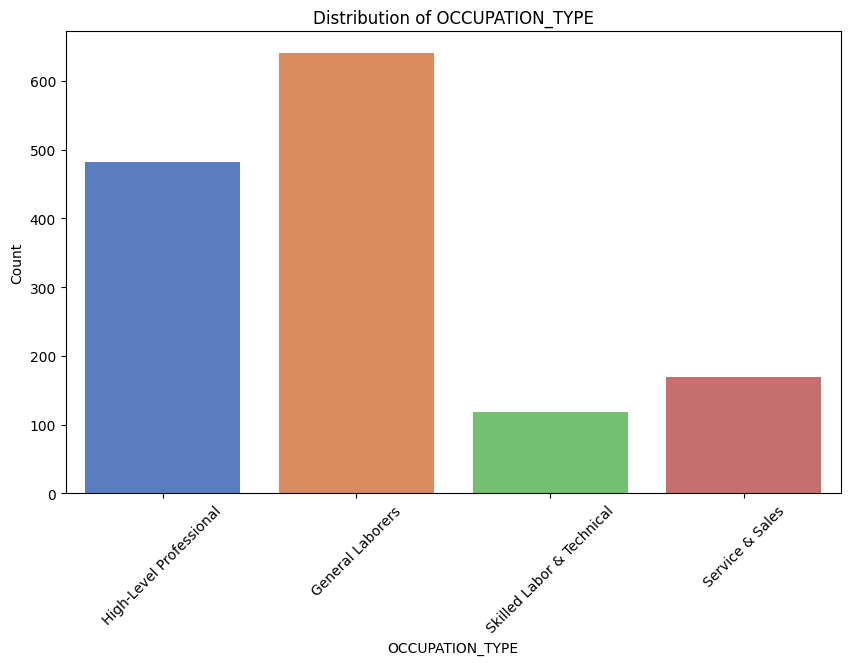

In [63]:
# Analyze high bad default rate in EDUCATION_TYPE = 'Lower secondary' and 'Incomplete higher'
high_default_education_type_lower_secondary = merged_application_record[merged_application_record["NAME_EDUCATION_TYPE"] == "Lower secondary"]
high_default_education_type_incomplete_higher = merged_application_record[merged_application_record["NAME_EDUCATION_TYPE"] == "Incomplete higher"]
dfs = {"Education_Type:Lower secondary": high_default_education_type_lower_secondary, "Education_Type:Incomplete higher": high_default_education_type_incomplete_higher}
for col in ["YEARS_EMPLOYED", "NAME_INCOME_TYPE", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"]:
    for name, df in dfs.items():
        print(f"Univariate Analyzing column: {col} when {name}")
        univariate_analyzer.execute_analysis(df=df, feature=col)

## 10.4. Own property vs Target


### 10.4.1. FLAG_OWN_CAR - TARGET


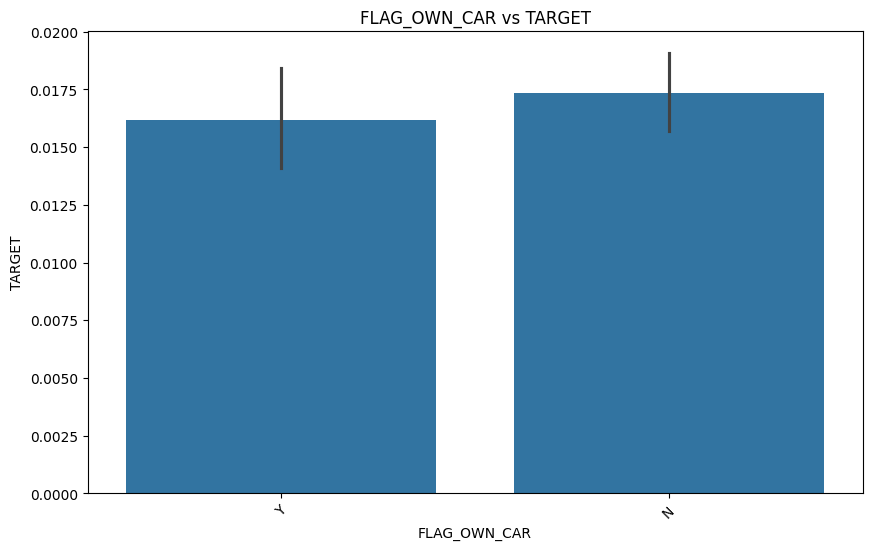

In [64]:
bivariate_analyzer.set_strategy(NumericalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df=merged_application_record, feature1="FLAG_OWN_CAR", feature2="TARGET", option="column_chart")

<h5 style="color:yellow">
Việc không sở hữu xe có tỷ lệ nợ xấu cao hơn. Đều này đúng với suy nghĩ thông thường khi người sở hữu xe riêng có tiềm năng kinh tế tốt hơn và ít nợ xấu.
</h5>


### 10.4.2. FLAG_OWN_REALTY - TARGET


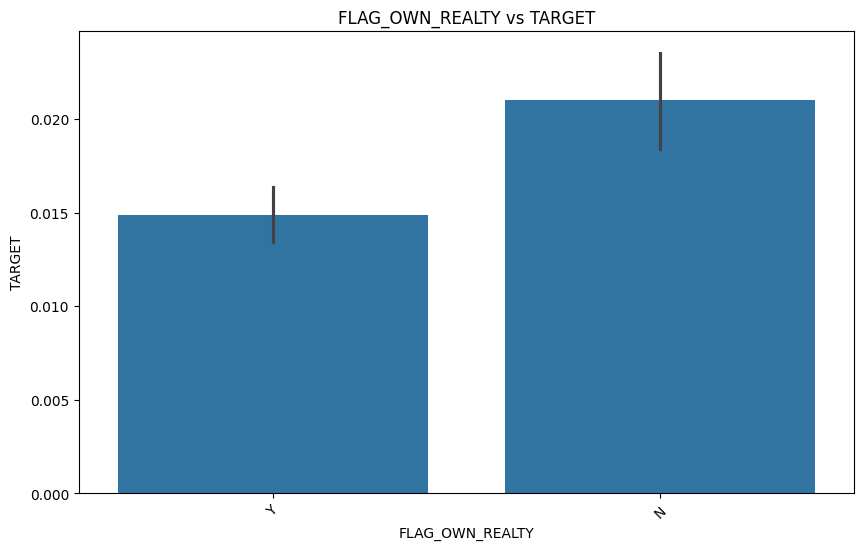

In [65]:
bivariate_analyzer.set_strategy(NumericalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df=merged_application_record, feature1="FLAG_OWN_REALTY", feature2="TARGET", option="column_chart")

<h5 style="color:yellow">
Tương tự với FLAG_OWN_CAR, việc không sở hữu bất động sản có tỷ lệ nợ xấu cao hơn một khoảng. 
</h5>


## 10.5. Income vs NAME_FAMILY_STATUS


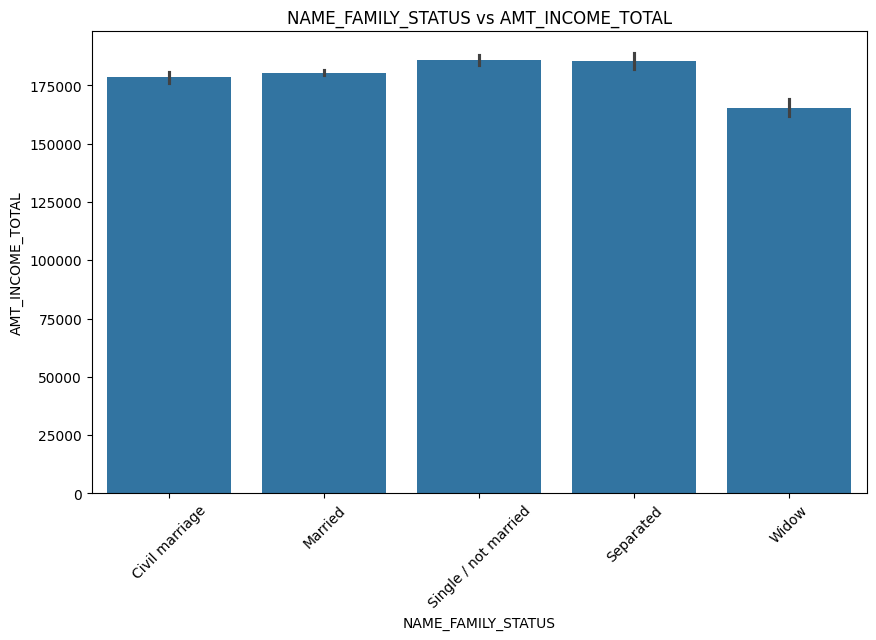

In [66]:
bivariate_analyzer.set_strategy(NumericalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df=merged_application_record, feature1="NAME_FAMILY_STATUS", feature2="AMT_INCOME_TOTAL", option="column_chart")

# **11. Multivariate Analysis**


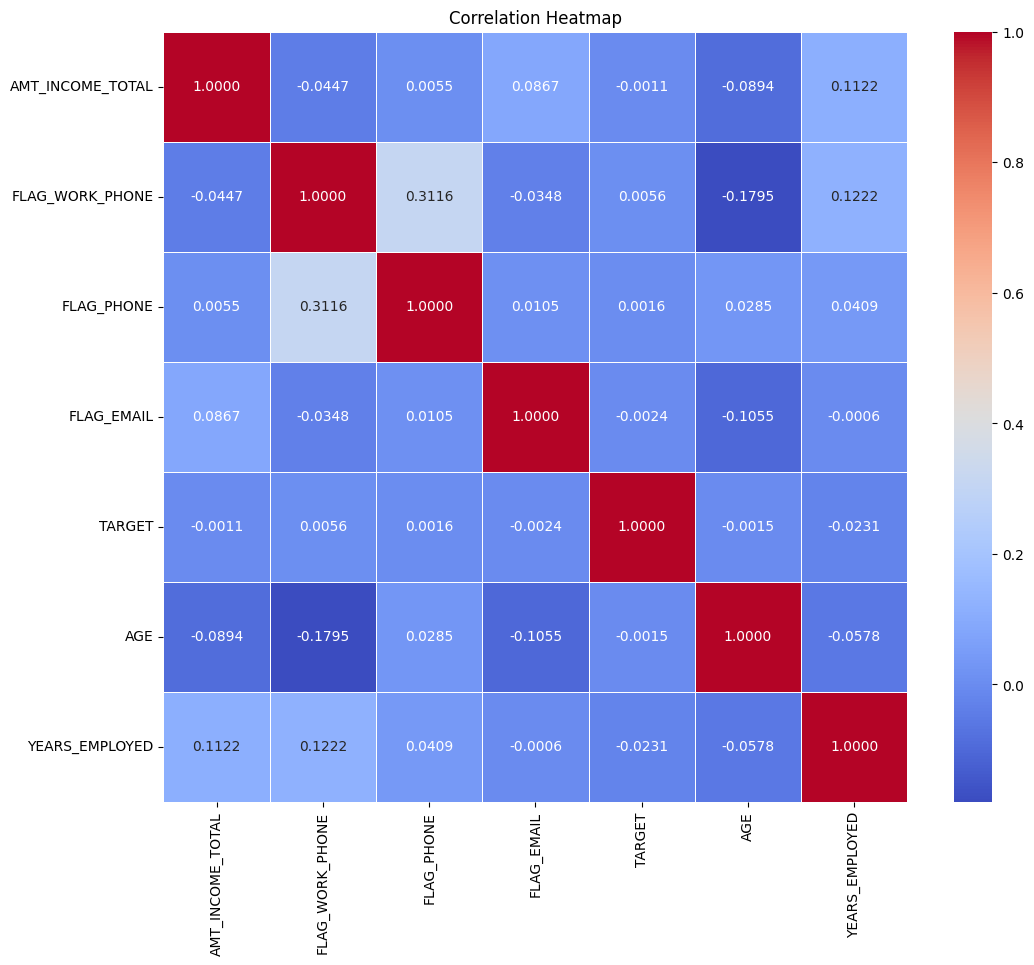

In [67]:
multivariate_analyzer = SimpleMultivariateAnalysis()
multivariate_analyzer.generate_correlation_heatmap(df=merged_application_record.drop(columns=["ID"]).select_dtypes(include=["number"]))

In [68]:
merged_application_record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   ID                      36457 non-null  int64   
 1   CODE_GENDER             36457 non-null  object  
 2   FLAG_OWN_CAR            36457 non-null  object  
 3   FLAG_OWN_REALTY         36457 non-null  object  
 4   AMT_INCOME_TOTAL        36457 non-null  float64 
 5   NAME_INCOME_TYPE        36457 non-null  object  
 6   NAME_EDUCATION_TYPE     36457 non-null  object  
 7   NAME_FAMILY_STATUS      36457 non-null  object  
 8   NAME_HOUSING_TYPE       36457 non-null  object  
 9   FLAG_WORK_PHONE         36457 non-null  int64   
 10  FLAG_PHONE              36457 non-null  int64   
 11  FLAG_EMAIL              36457 non-null  int64   
 12  OCCUPATION_TYPE         36457 non-null  object  
 13  TARGET                  36457 non-null  int64   
 14  AGE                   

In [70]:
cnt_label_0 = merged_application_record[merged_application_record["TARGET"] == 0].shape[0]
cnt_label_1 = merged_application_record[merged_application_record["TARGET"] == 1].shape[0]
print(f"Count of TARGET = 0: {cnt_label_0}")
print(f"Count of TARGET = 1: {cnt_label_1}")

Count of TARGET = 0: 35841
Count of TARGET = 1: 616


In [69]:
merged_application_record.to_csv("../datawarehouse/data_cleaned.csv", index=False)